***Importing Libraries***

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import seaborn as sns

***Importing Dataset and SMOTE***

In [2]:
import numpy as np
import pandas as pd

# -----------------------------
# Paths & settings
# -----------------------------
DATA_PATH   = "second_collected_data.csv"
OUT_PATH    = "augmented_second_with_modular.csv"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Ratio clamp (domain check!)
RATIO_MIN, RATIO_MAX = 0.70, 1.30   # <-- adjust to what’s realistic for your domain

# Balance options: "downsample", "oversample", or None
BALANCE_MODE = "downsample"         # you had downsampling to hit ~50/50
TARGET_SHARE = 0.50                 # aim for 50/50

# Optional small noise on synthetic Modular cost so it’s not a pure multiple
ADD_NOISE           = True
NOISE_SD_PCT_FALLBK = 0.08          # 8% stdev fallback if residual pool is small

# -----------------------------
# 1) Load & tidy
# -----------------------------
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df = df.rename(columns={"Type of Building":"Type", "Initial Cost ":"Initial Cost", "Area ":"Area"})

# numeric dtypes
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# string normalization (consistent keys)
for c in ["Type","Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# gently normalize cases
df["Type"]     = df["Type"].str.capitalize()
if "Country" in df:  df["Country"]  = df["Country"].str.title()
if "Location" in df: df["Location"] = df["Location"].str.title()
if "Material" in df: df["Material"] = df["Material"].str.title()

feature_cols = ["Area","Year","Location","Country","Number of Floors","Material"]
target = "Initial Cost"

df = df.dropna(subset=["Type", target] + feature_cols).reset_index(drop=True)

# -----------------------------
# 2) Learn Modular/Conventional cost ratios (hierarchical fallback)
# -----------------------------
def area_bin(a, width=50):
    return int(np.floor(a / width) * width)

work = df.copy()
work["area_bin"] = work["Area"].apply(area_bin)

is_mod  = work["Type"].str.lower().eq("modular")
is_conv = work["Type"].str.lower().eq("conventional")

def median_ratio(group_cols):
    m_conv = work[is_conv].groupby(group_cols)[target].median()
    m_mod  = work[is_mod ].groupby(group_cols)[target].median()
    common = m_conv.index.intersection(m_mod.index)
    if len(common) == 0:
        return pd.Series(dtype=float)
    rat = (m_mod.loc[common] / m_conv.loc[common]).clip(RATIO_MIN, RATIO_MAX)
    return rat

ratio_maps = [
    (["Country","Location","Material","Number of Floors","area_bin"], median_ratio(["Country","Location","Material","Number of Floors","area_bin"])),
    (["Country","Location","Material","Number of Floors"],            median_ratio(["Country","Location","Material","Number of Floors"])),
    (["Country","Location","Material","area_bin"],                    median_ratio(["Country","Location","Material","area_bin"])),
    (["Country","Material","Number of Floors","area_bin"],            median_ratio(["Country","Material","Number of Floors","area_bin"])),
    (["Country","Material","Number of Floors"],                       median_ratio(["Country","Material","Number of Floors"])),
    (["Country","Material"],                                          median_ratio(["Country","Material"])),
    (["Country","Number of Floors","area_bin"],                       median_ratio(["Country","Number of Floors","area_bin"])),
    (["Country","Number of Floors"],                                  median_ratio(["Country","Number of Floors"])),
    (["Location"],                                                    median_ratio(["Location"])),
    (["Country"],                                                     median_ratio(["Country"])),
    (["Material"],                                                    median_ratio(["Material"])),
    (["area_bin"],                                                    median_ratio(["area_bin"])),
]

# global fallback
if is_mod.sum() and is_conv.sum():
    global_ratio = float(np.clip(work[is_mod][target].median() / work[is_conv][target].median(),
                                 RATIO_MIN, RATIO_MAX))
else:
    global_ratio = 1.00  # if one class missing entirely, neutral fallback

def ratio_for_row(row):
    for cols, m in ratio_maps:
        key = tuple(row[c] if c != "area_bin" else area_bin(row["Area"]) for c in cols)
        if key in m.index:
            return float(m.loc[key])
    return global_ratio

# -----------------------------
# 3) Identify missing Modular combos & synthesize
# -----------------------------
key_cols = feature_cols  # exact match on these features

conv = df[df["Type"].str.lower()=="conventional"].copy()
mod  = df[df["Type"].str.lower()=="modular"].copy()

# Use tuple keys (robust vs string formatting issues)
conv_keys = set(conv[key_cols].apply(lambda r: tuple(r.values.tolist()), axis=1))
mod_keys  = set(mod [key_cols].apply(lambda r: tuple(r.values.tolist()), axis=1))

missing_for_mod = conv[~conv[key_cols].apply(lambda r: tuple(r.values.tolist()), axis=1).isin(mod_keys)]

# --- Optional residual pool (to add realistic noise) ---
residuals = []
if ADD_NOISE and len(mod) and len(conv):
    # map modular exact keys to their observed costs (only where exact match exists)
    mod_map = mod.set_index(key_cols)[target].to_dict()
    for _, crow in conv.iterrows():
        k = tuple(crow[c] for c in key_cols)
        if k in mod_map:
            r = ratio_for_row(crow)
            residuals.append(mod_map[k] - r * float(crow[target]))
    residuals = pd.Series(residuals, dtype=float)
    # remove extreme outliers in residual pool
    if len(residuals):
        q1, q3 = residuals.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 3*iqr, q3 + 3*iqr
        residuals = residuals[(residuals >= lo) & (residuals <= hi)]

synthetic_rows = []
for _, row in missing_for_mod.iterrows():
    new = row.copy()
    new["Type"] = "Modular"
    r = ratio_for_row(row)
    base_cost = float(row[target]) * r
    if ADD_NOISE:
        if len(residuals) >= 30:
            noise = float(residuals.sample(n=1, random_state=np.random.randint(0,1_000_000)))
            new[target] = base_cost + noise
        else:
            # fallback: mild multiplicative noise
            pct = np.random.normal(loc=0.0, scale=NOISE_SD_PCT_FALLBK)
            new[target] = base_cost * (1.0 + pct)
    else:
        new[target] = base_cost
    synthetic_rows.append(new)

synthetic_mod_df = (pd.DataFrame(synthetic_rows)
                    if len(synthetic_rows) else
                    pd.DataFrame(columns=df.columns))

aug = pd.concat([df, synthetic_mod_df], ignore_index=True)

# -----------------------------
# 4) Balance to ~50/50
# -----------------------------
if BALANCE_MODE is not None:
    mod_mask  = aug["Type"].str.lower()=="modular"
    conv_mask = aug["Type"].str.lower()=="conventional"
    n_mod, n_conv = int(mod_mask.sum()), int(conv_mask.sum())
    n_total = n_mod + n_conv
    if n_total > 0:
        target_n_mod = int(round(TARGET_SHARE * n_total))
        target_n_conv = n_total - target_n_mod

        if BALANCE_MODE == "downsample":
            if n_mod > target_n_mod:
                drop_idx = aug[mod_mask].sample(n=n_mod - target_n_mod, random_state=RANDOM_STATE).index
                aug = aug.drop(index=drop_idx)
            if n_conv > target_n_conv:
                drop_idx = aug[conv_mask].sample(n=n_conv - target_n_conv, random_state=RANDOM_STATE).index
                aug = aug.drop(index=drop_idx)
        elif BALANCE_MODE == "oversample":
            # simple random oversample (no new feature values invented)
            if n_mod < target_n_mod and n_mod > 0:
                add = aug[mod_mask].sample(n=target_n_mod - n_mod, replace=True, random_state=RANDOM_STATE)
                aug = pd.concat([aug, add], ignore_index=True)
            if n_conv < target_n_conv and n_conv > 0:
                add = aug[conv_mask].sample(n=target_n_conv - n_conv, replace=True, random_state=RANDOM_STATE)
                aug = pd.concat([aug, add], ignore_index=True)

    aug = aug.reset_index(drop=True)

# -----------------------------
# 5) Save & coverage checks
# -----------------------------
aug = aug[["Type","Area","Year","Location","Country","Number of Floors","Material","Initial Cost"]].copy()
aug.to_csv(OUT_PATH, index=False)
print("Saved ->", OUT_PATH)

share = aug["Type"].value_counts(normalize=True).round(3).to_dict()
print("Class share:", share)

def in_any_gap(a):
    return any(lo <= a <= hi for lo,hi in [(1202,1452),(1576,1768)])

print("Modular rows in area gaps:",
      int(((aug["Type"]=="Modular") & (aug["Area"].apply(in_any_gap))).sum()))
print("Has Modular in Canada? ", bool(((aug["Type"]=="Modular") & (aug["Country"]=="Canada")).any()))
print("Modular floors present:", sorted(aug.loc[aug["Type"]=="Modular","Number of Floors"].unique()))
print("Modular materials present:", sorted(aug.loc[aug["Type"]=="Modular","Material"].unique()))
print("Sample Modular locations in Canada:",
      sorted(aug.loc[(aug["Type"]=="Modular") & (aug["Country"]=="Canada"), "Location"].unique())[:10])


Saved -> augmented_second_with_modular.csv
Class share: {'Modular': 0.504, 'Conventional': 0.496}
Modular rows in area gaps: 9917
Has Modular in Canada?  True
Modular floors present: [np.float64(1.0), np.float64(1.5), np.float64(2.0)]
Modular materials present: ['Brick Veneer Wood Frame', 'Stucco On Wood Frame', 'Vinyl Siding Wood Frame', 'Wood Siding Wood Frame']
Sample Modular locations in Canada: ['Alberta', 'British Columbia', 'Manitoba', 'New Brunswick', 'Newfoundland', 'Nova Scotia', 'Ontario', 'Prince Edward Island', 'Quebec', 'Saskatchewan']


***Data Distribution***

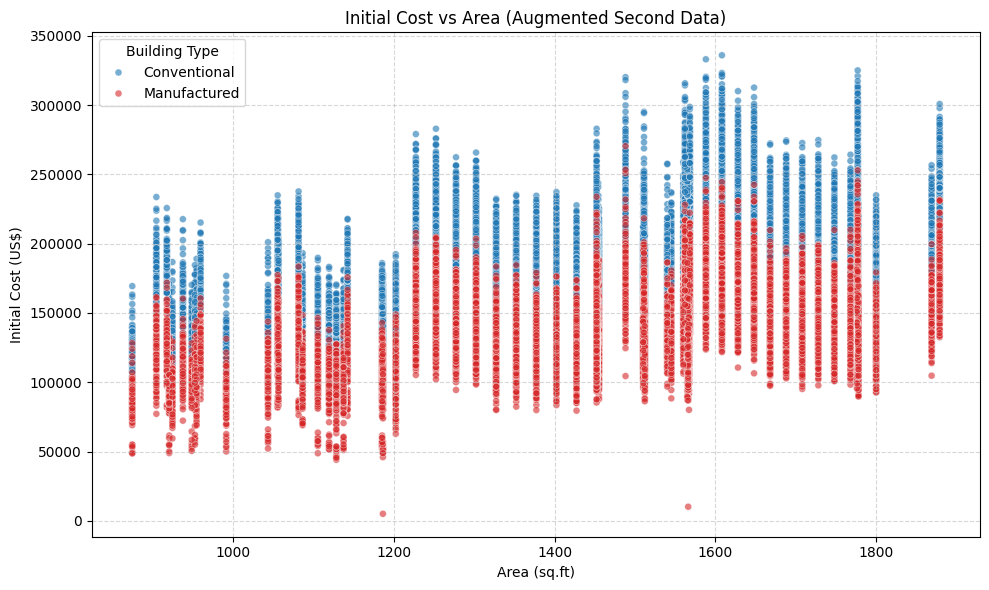

Saved to: E:\PhD Related Documents\Codes\ml_projects\lcc\New Figures


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Load augmented dataset
df_aug = pd.read_csv("augmented_second_with_modular.csv")
df_aug.columns = df_aug.columns.str.strip()

# ---- Create plotting label (Modular -> Manufactured) ----
df_aug["Type_label"] = (
    df_aug["Type"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace({"Modular": "Manufactured"})
)

# Define order and strong colors
hue_order = ["Conventional", "Manufactured"]

palette = {
    "Conventional": "#1f77b4",   # deep blue
    "Manufactured": "#d62728"    # strong red
}

# Plot scatterplot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_aug,
    x="Area",
    y="Initial Cost",
    hue="Type_label",
    hue_order=hue_order,
    palette=palette,
    alpha=0.6,
    s=25
)

plt.title("Initial Cost vs Area (Augmented Second Data)")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Initial Cost (US$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Building Type")
plt.tight_layout()

# ---- Save to New Figures folder ----
base_dir = Path(r"E:\PhD Related Documents\Codes\ml_projects\lcc")
out_dir = base_dir / "New Figures"
out_dir.mkdir(exist_ok=True)

plt.savefig(out_dir / "augmented_second_data.png", dpi=600, bbox_inches="tight")
plt.savefig(out_dir / "augmented_second_data.pdf", bbox_inches="tight")

plt.show()

print("Saved to:", out_dir)


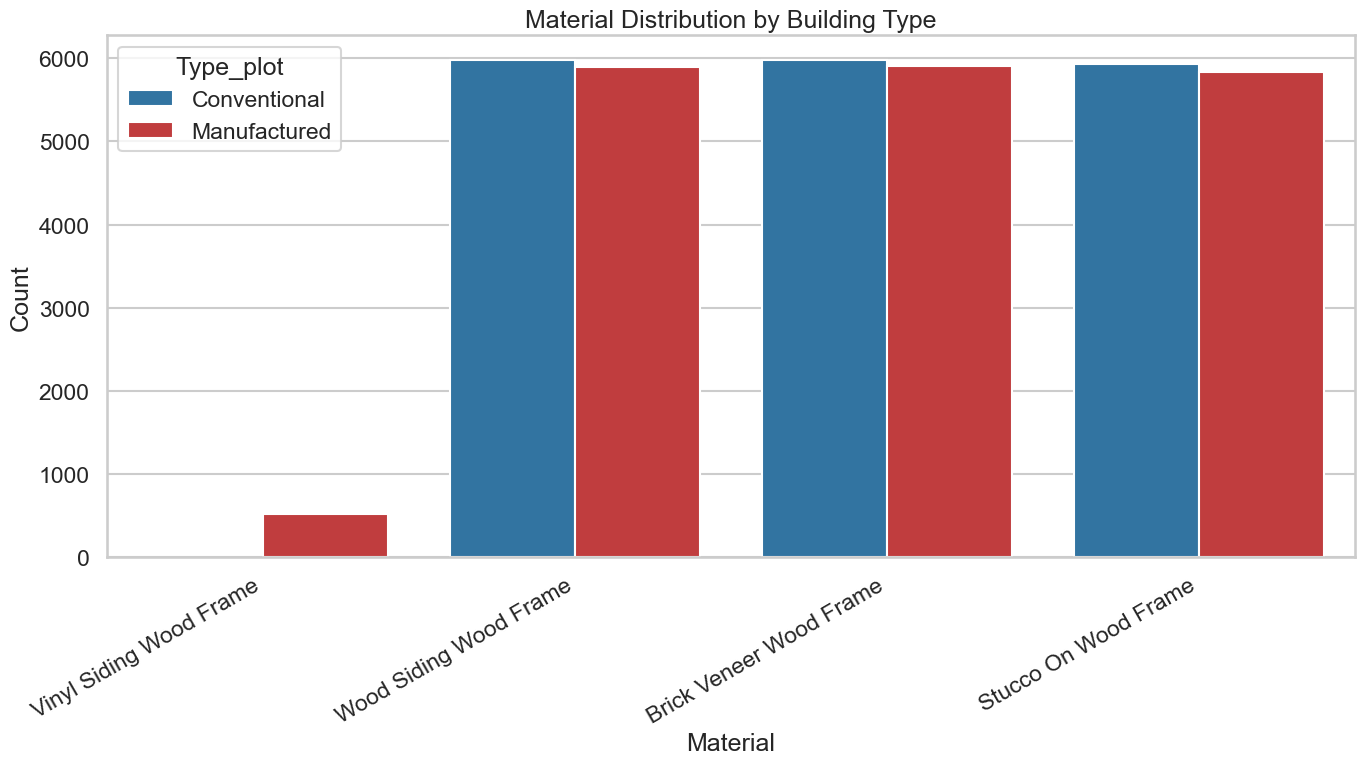

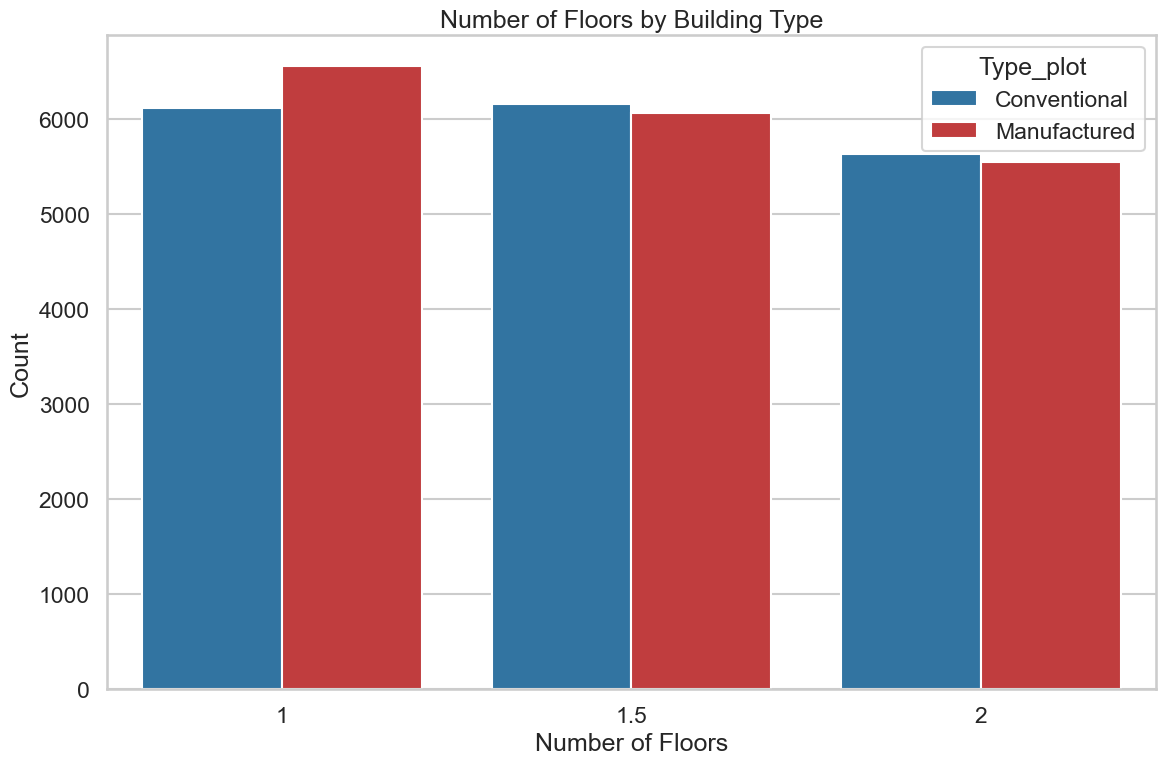

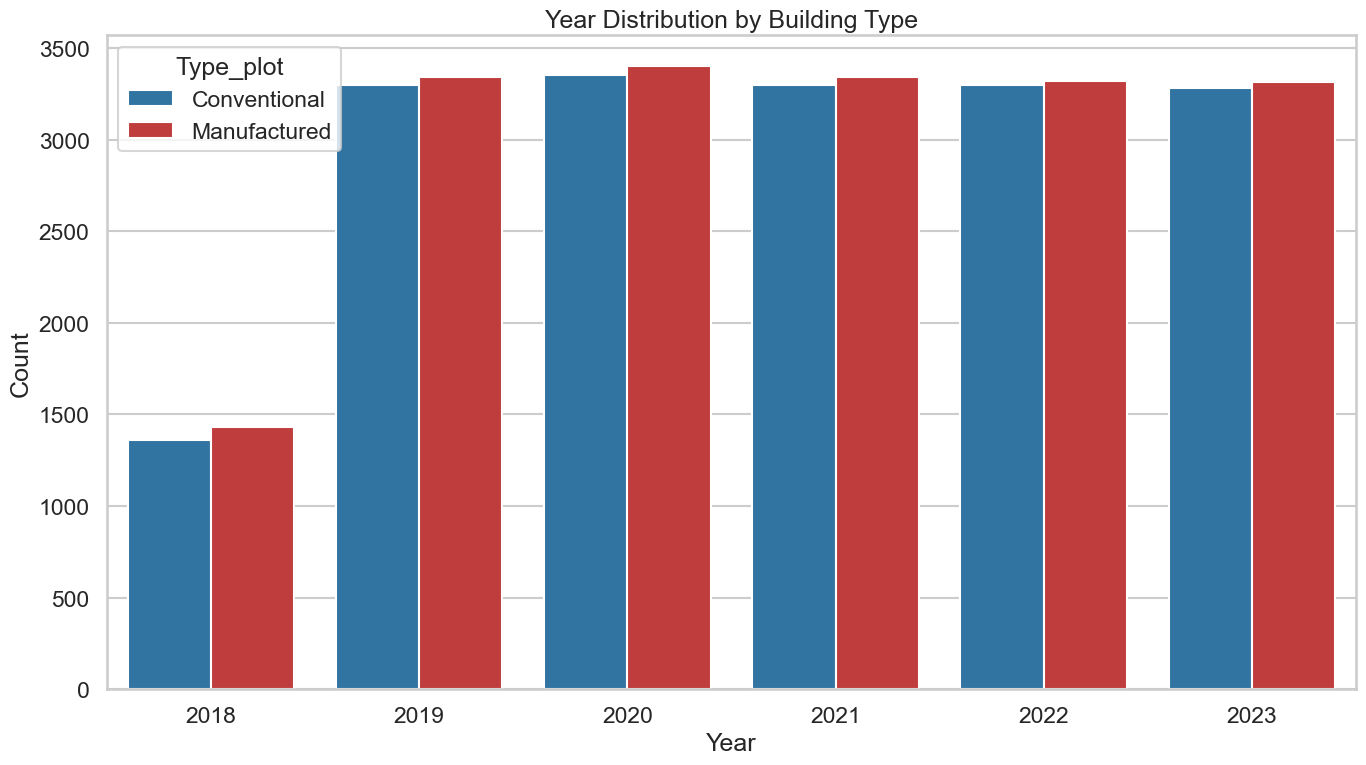

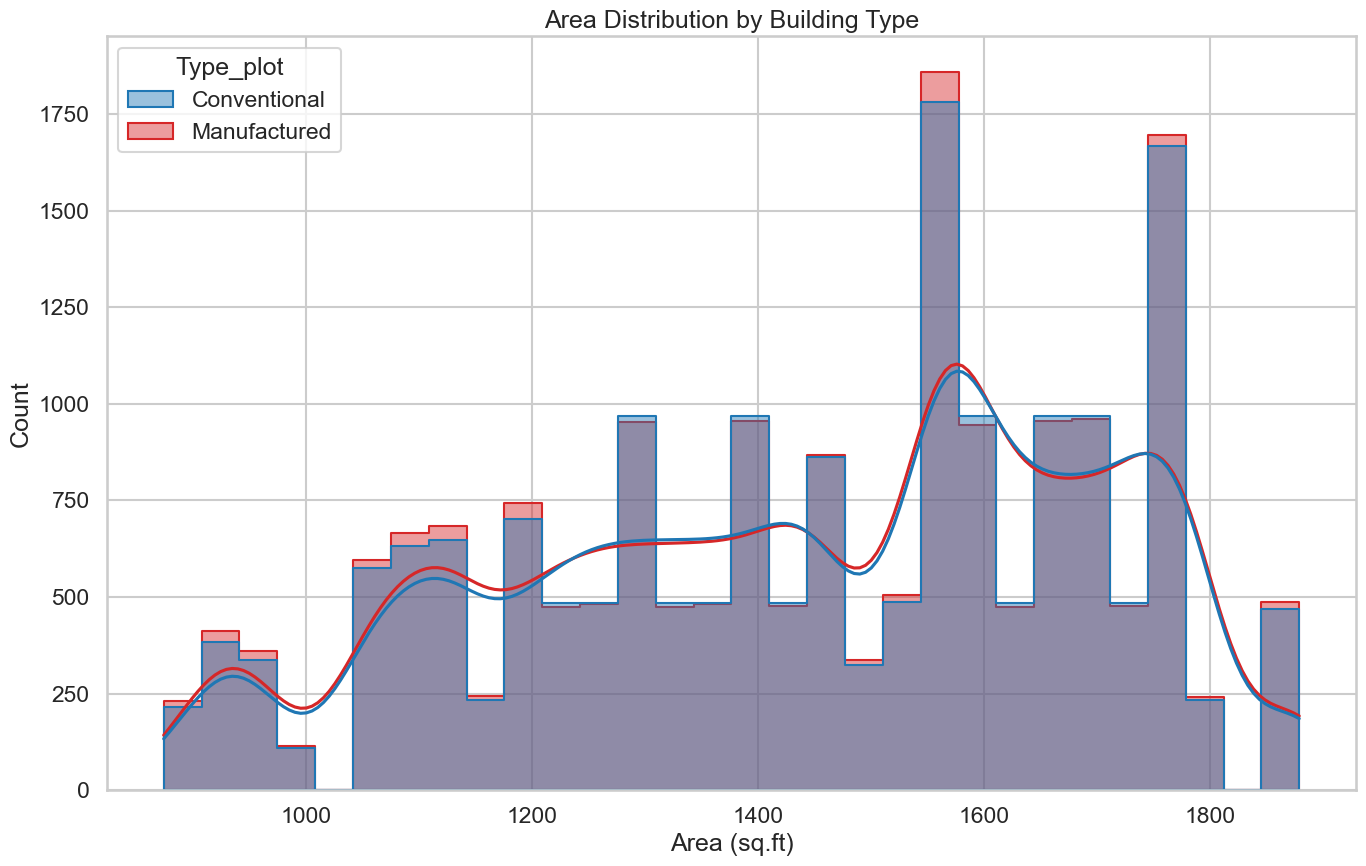

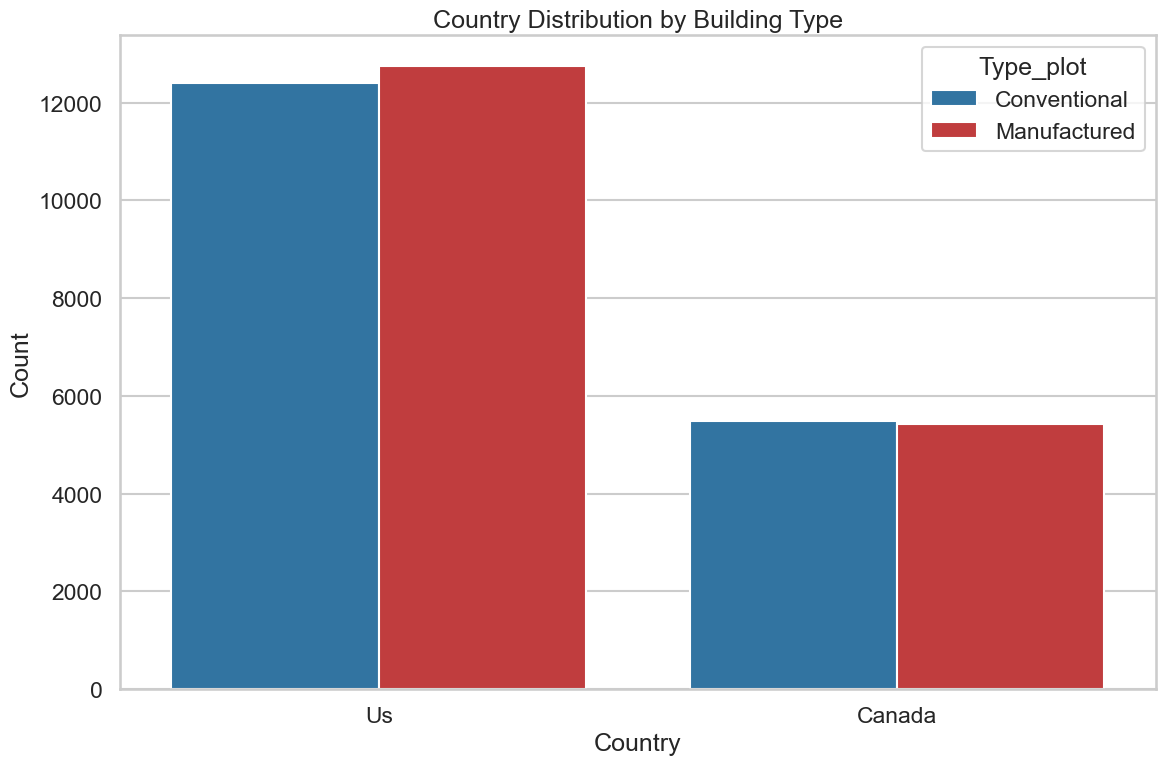

All figures saved to: E:\PhD Related Documents\Codes\ml_projects\lcc\New Figures


In [4]:
# === Plots for augmented_second_with_modular.csv ============================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

AUG_PATH = "augmented_second_with_modular.csv"

sns.set_theme(style="whitegrid", context="talk")

# ---------- Load & tidy ----------
df = pd.read_csv(AUG_PATH)
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns={"Type of Building":"Type",
                        "Initial Cost ":"Initial Cost",
                        "Area ":"Area"})

# normalize Type labels
if "Type" not in df.columns:
    raise ValueError("Column 'Type' not found.")

df["Type"] = df["Type"].astype(str).str.strip().str.title()
df["Type"] = np.where(df["Type"].str.lower().str.contains("mod"),
                      "Modular", "Conventional")

# ---- Create plotting label ----
df["Type_plot"] = df["Type"].replace({"Modular": "Manufactured"})

# numeric enforcement
for c in ["Area", "Year", "Number of Floors", "Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# helper columns
df["Floors_str"] = df["Number of Floors"].map(lambda x: f"{x:g}")
year_order = sorted(df["Year"].dropna().unique())

# consistent plotting order & palette
hue_order = ["Conventional", "Manufactured"]
palette = {
    "Conventional": "#1f77b4",
    "Manufactured": "#d62728"
}

# ---------- Save directory ----------
base_dir = Path(r"E:\PhD Related Documents\Codes\ml_projects\lcc")
out_dir = base_dir / "New Figures"
out_dir.mkdir(exist_ok=True)

# ========== 1) Material Distribution ==========
plt.figure(figsize=(14,8))
ax = sns.countplot(data=df, x="Material",
                   hue="Type_plot",
                   hue_order=hue_order,
                   palette=palette)
ax.set_title("Material Distribution by Building Type")
ax.set_xlabel("Material"); ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(out_dir / "material_distribution_aug2.png", dpi=600, bbox_inches="tight")
plt.savefig(out_dir / "material_distribution_aug2.pdf", bbox_inches="tight")
plt.show()

# ========== 2) Floors Distribution ==========
plt.figure(figsize=(12,8))
ax = sns.countplot(data=df, x="Floors_str",
                   hue="Type_plot",
                   hue_order=hue_order,
                   palette=palette)
ax.set_title("Number of Floors by Building Type")
ax.set_xlabel("Number of Floors"); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(out_dir / "floors_distribution_aug2.png", dpi=600, bbox_inches="tight")
plt.savefig(out_dir / "floors_distribution_aug2.pdf", bbox_inches="tight")
plt.show()

# ========== 3) Year Distribution ==========
plt.figure(figsize=(14,8))
ax = sns.countplot(data=df, x="Year",
                   hue="Type_plot",
                   order=year_order,
                   hue_order=hue_order,
                   palette=palette)
ax.set_title("Year Distribution by Building Type")
ax.set_xlabel("Year"); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(out_dir / "year_distribution_aug2.png", dpi=600, bbox_inches="tight")
plt.savefig(out_dir / "year_distribution_aug2.pdf", bbox_inches="tight")
plt.show()

# ========== 4) Area Distribution ==========
plt.figure(figsize=(14,9))
ax = sns.histplot(
    data=df,
    x="Area",
    hue="Type_plot",
    bins=30,
    kde=True,
    element="step",
    stat="count",
    common_norm=False,
    alpha=0.45,
    hue_order=hue_order,
    palette=palette
)
ax.set_title("Area Distribution by Building Type")
ax.set_xlabel("Area (sq.ft)"); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(out_dir / "area_distribution_aug2.png", dpi=600, bbox_inches="tight")
plt.savefig(out_dir / "area_distribution_aug2.pdf", bbox_inches="tight")
plt.show()

# ========== 5) Country Distribution ==========
plt.figure(figsize=(12,8))
ax = sns.countplot(data=df, x="Country",
                   hue="Type_plot",
                   hue_order=hue_order,
                   palette=palette)
ax.set_title("Country Distribution by Building Type")
ax.set_xlabel("Country"); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(out_dir / "country_distribution_aug2.png", dpi=600, bbox_inches="tight")
plt.savefig(out_dir / "country_distribution_aug2.pdf", bbox_inches="tight")
plt.show()

print("All figures saved to:", out_dir)

***Verify Synthetic Data***

***Kolmogorov-Smirnov KS Test***

Sample counts:
- Conventional: 17889
- Real Manufactured: 528
- Synthetic Manufactured: 17635


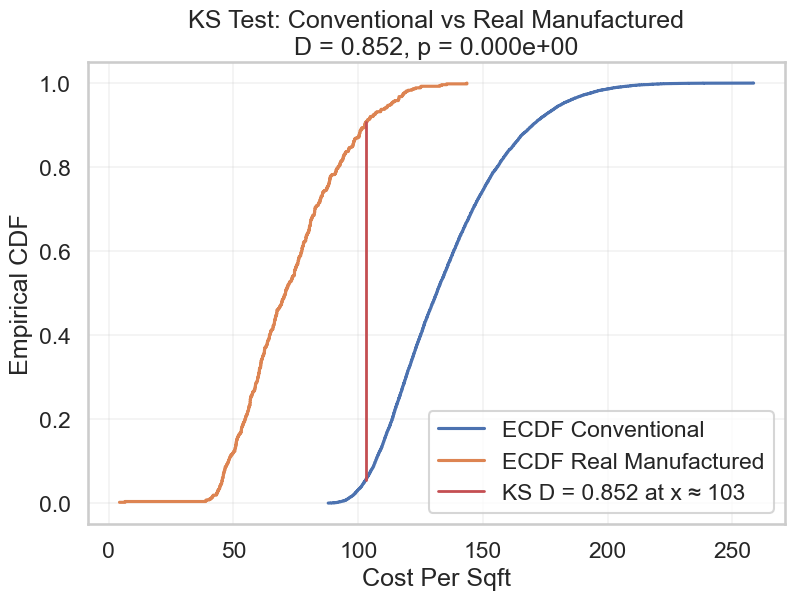

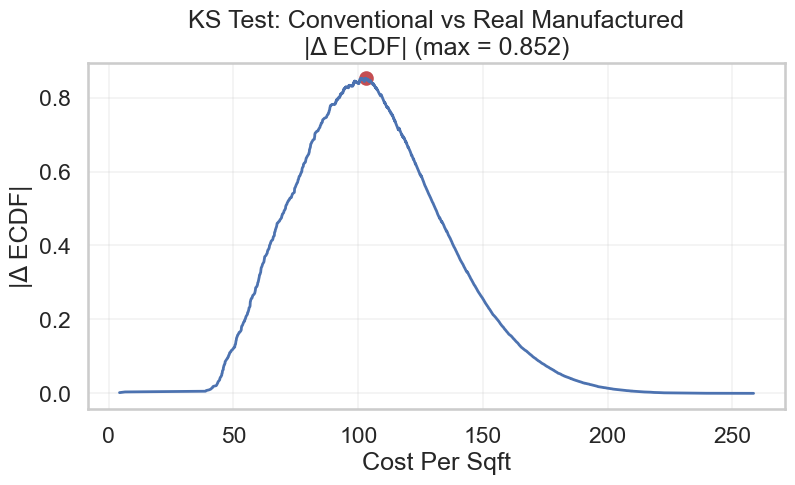

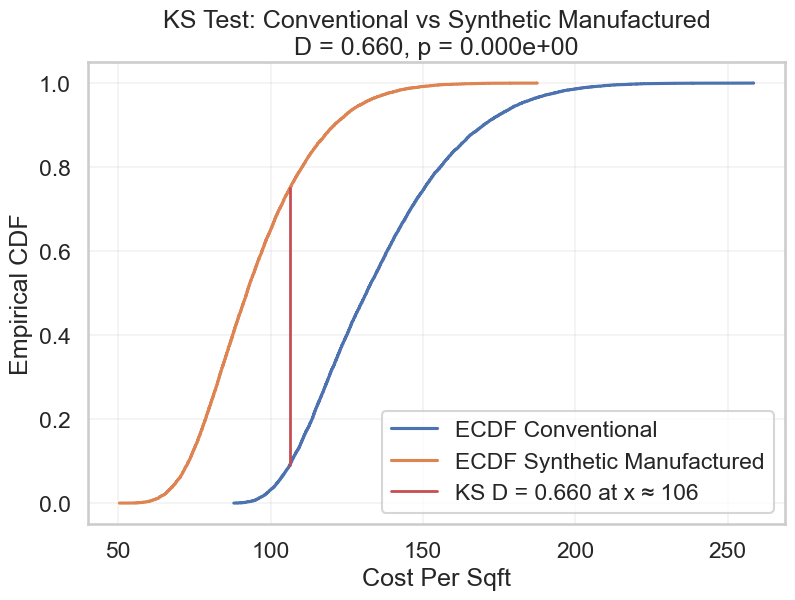

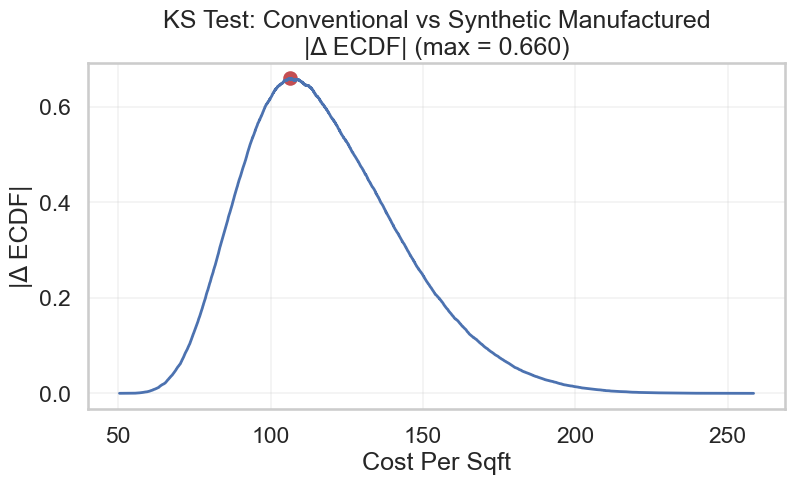

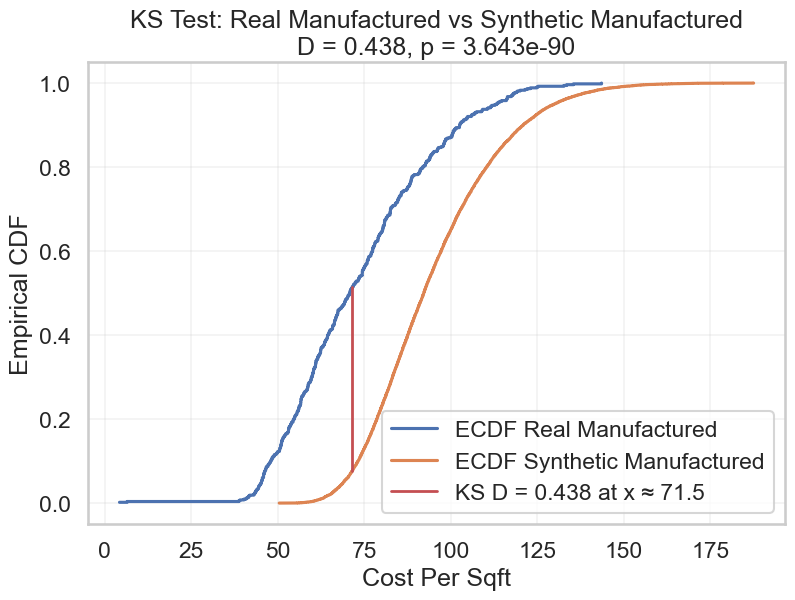

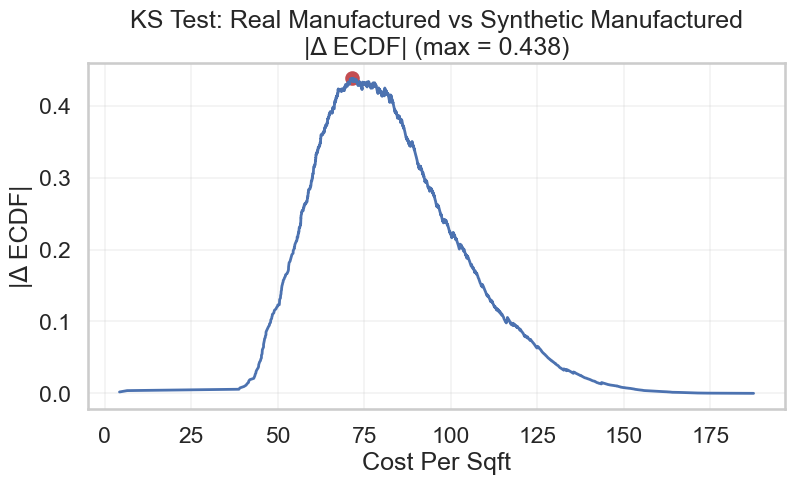


KS Test Summary:


,D,p_value,x_at_D
Comparison,,,
Conv_vs_RealManu,0.852191,0.000000e+00,103.00
Conv_vs_SynManu,0.659641,0.000000e+00,106.29
RealManu_vs_SynManu,0.438202,3.643412e-90,71.54



Saved figures to: E:\PhD Related Documents\Codes\ml_projects\lcc\New Figures


In [5]:
# === Kolmogorov–Smirnov tests and ECDF difference plots ======================
# Files expected in the same folder as this notebook:
#   - real_conventional_data.csv
#   - real_modular_data.csv
#   - synthetic_modular_data.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from pathlib import Path

# -------------------------
# 1) Config & helpers
# -------------------------
FILE_CONV = Path("real_conventional_data.csv")
FILE_REAL_MOD = Path("real_modular_data.csv")
FILE_SYN_MOD = Path("synthetic_modular_data.csv")
COL_NAME = "Cost Per Sqft"

# Save folder
BASE_DIR = Path(r"E:\PhD Related Documents\Codes\ml_projects\lcc")
OUT_DIR = BASE_DIR / "New Figures"
OUT_DIR.mkdir(exist_ok=True)

SAVE_DPI = 600  # match your other plots

def to_numeric_series(x):
    """Clean and convert a pandas Series to numeric."""
    s = x.astype(str).str.strip()
    s = s.str.replace(r"[,\$\€\£]", "", regex=True)
    s = pd.to_numeric(s, errors="coerce")
    return s

def load_costs(path, col=COL_NAME):
    df = pd.read_csv(path)
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in {path.name}. Columns: {list(df.columns)}")
    s = to_numeric_series(df[col]).dropna()
    return s.values

def ecdf(values):
    v = np.sort(np.asarray(values))
    y = np.arange(1, v.size+1) / v.size
    return v, y

def ks_diff_curve(x, a_vals, b_vals):
    def F(sample, t):
        return np.searchsorted(sample, t, side="right") / sample.size
    Fa = np.array([F(a_vals, xi) for xi in x])
    Fb = np.array([F(b_vals, xi) for xi in x])
    diff = np.abs(Fa - Fb)
    return Fa, Fb, diff

def plot_ecdfs_with_D(a_vals, b_vals, label_a, label_b, title_prefix, savepath_stem=None):
    a_sorted, a_cdf = ecdf(a_vals)
    b_sorted, b_cdf = ecdf(b_vals)

    ks_res = ks_2samp(a_vals, b_vals)
    D, p = ks_res.statistic, ks_res.pvalue

    x = np.unique(np.concatenate([a_sorted, b_sorted]))
    Fa, Fb, diff = ks_diff_curve(x, a_sorted, b_sorted)
    i_max = int(np.argmax(diff))
    x_star = x[i_max]
    Fa_star, Fb_star, D_star = Fa[i_max], Fb[i_max], diff[i_max]

    # --- Figure 1: ECDFs ---
    plt.figure(figsize=(9, 6))
    plt.step(a_sorted, a_cdf, where="post", label=f"ECDF {label_a}")
    plt.step(b_sorted, b_cdf, where="post", label=f"ECDF {label_b}")
    plt.plot([x_star, x_star], [Fa_star, Fb_star], "r-", lw=2,
             label=f"KS D = {D_star:.3f} at x ≈ {x_star:.3g}")
    plt.title(f"{title_prefix}\nD = {D:.3f}, p = {p:.3e}")
    plt.xlabel("Cost Per Sqft")
    plt.ylabel("Empirical CDF")
    plt.grid(True, linewidth=0.3)
    plt.legend()

    if savepath_stem:
        plt.savefig(OUT_DIR / f"{savepath_stem}_ECDF.png", dpi=SAVE_DPI, bbox_inches="tight")
        plt.savefig(OUT_DIR / f"{savepath_stem}_ECDF.pdf", bbox_inches="tight")
    plt.show()

    # --- Figure 2: Difference curve ---
    plt.figure(figsize=(9, 4.5))
    plt.plot(x, diff, lw=2)
    plt.scatter([x_star], [D_star], c="r")
    plt.title(f"{title_prefix}\n|Δ ECDF| (max = {D:.3f})")
    plt.xlabel("Cost Per Sqft")
    plt.ylabel("|Δ ECDF|")
    plt.grid(True, linewidth=0.3)

    if savepath_stem:
        plt.savefig(OUT_DIR / f"{savepath_stem}_DIFF.png", dpi=SAVE_DPI, bbox_inches="tight")
        plt.savefig(OUT_DIR / f"{savepath_stem}_DIFF.pdf", bbox_inches="tight")
    plt.show()

    return {"D": float(D), "p_value": float(p), "x_at_D": float(x_star)}

# -------------------------
# 2) Load data
# -------------------------
conv_vals = load_costs(FILE_CONV)
real_mod_vals = load_costs(FILE_REAL_MOD)
syn_mod_vals  = load_costs(FILE_SYN_MOD)

print("Sample counts:")
print(f"- Conventional: {len(conv_vals)}")
print(f"- Real Manufactured: {len(real_mod_vals)}")
print(f"- Synthetic Manufactured: {len(syn_mod_vals)}")

# -------------------------
# 3) Run KS tests (Modular -> Manufactured in labels/titles)
# -------------------------
results = {}

results["Conv_vs_RealManu"] = plot_ecdfs_with_D(
    conv_vals, real_mod_vals,
    "Conventional", "Real Manufactured",
    "KS Test: Conventional vs Real Manufactured",
    savepath_stem="KS_Conv_vs_RealManufactured"
)

results["Conv_vs_SynManu"] = plot_ecdfs_with_D(
    conv_vals, syn_mod_vals,
    "Conventional", "Synthetic Manufactured",
    "KS Test: Conventional vs Synthetic Manufactured",
    savepath_stem="KS_Conv_vs_SyntheticManufactured"
)

results["RealManu_vs_SynManu"] = plot_ecdfs_with_D(
    real_mod_vals, syn_mod_vals,
    "Real Manufactured", "Synthetic Manufactured",
    "KS Test: Real Manufactured vs Synthetic Manufactured",
    savepath_stem="KS_RealManufactured_vs_SyntheticManufactured"
)

# -------------------------
# 4) Summary
# -------------------------
summary = pd.DataFrame(results).T
summary.index.name = "Comparison"
print("\nKS Test Summary:")
display(summary)

print("\nSaved figures to:", OUT_DIR)


***t-test***

In [2]:
import pandas as pd
from scipy.stats import ttest_ind

# Load files
real_conv = pd.read_csv("real_conventional_data.csv")
real_mod  = pd.read_csv("real_modular_data.csv")
syn_mod   = pd.read_csv("synthetic_modular_data.csv")

# Ensure numeric
for df in [real_conv, real_mod, syn_mod]:
    df["Cost Per Sqft"] = pd.to_numeric(df["Cost Per Sqft"], errors="coerce")

conv_vals = real_conv["Cost Per Sqft"].dropna()
real_mod_vals = real_mod["Cost Per Sqft"].dropna()
syn_mod_vals = syn_mod["Cost Per Sqft"].dropna()

# t-tests
t_conv_vs_real = ttest_ind(conv_vals, real_mod_vals, equal_var=False)  # Welch’s t-test
t_conv_vs_syn  = ttest_ind(conv_vals, syn_mod_vals, equal_var=False)
t_real_vs_syn  = ttest_ind(real_mod_vals, syn_mod_vals, equal_var=False)

print("Conventional vs Real Modular:", t_conv_vs_real)
print("Conventional vs Synthetic Modular:", t_conv_vs_syn)
print("Real Modular vs Synthetic Modular:", t_real_vs_syn)


Conventional vs Real Modular: TtestResult(statistic=np.float64(66.20917911980058), pvalue=np.float64(6.189264491968193e-270), df=np.float64(570.4650127466442))
Conventional vs Synthetic Modular: TtestResult(statistic=np.float64(173.54647695971553), pvalue=np.float64(0.0), df=np.float64(33444.340876756585))
Real Modular vs Synthetic Modular: TtestResult(statistic=np.float64(-23.222525722117826), pvalue=np.float64(9.242647432470455e-84), df=np.float64(552.5239299845729))


***Pearson and Spearman Correlation***

In [3]:
# =================== Correlation comparison: Real vs Modular/Synthetic ===================
# Expects the files in the same folder as your notebook:
#   - real_conventional_data.csv
#   - real_modular_data.csv
#   - synthetic_modular_data.csv
#
# Outputs:
#   - Two summary DataFrames:
#       1) Conv vs RealMod  (Pearson & Spearman for numeric; η and Spearman(label) for categorical)
#       2) Conv vs SynMod   (same)
#
# Notes:
#   * Pearson/Spearman are meaningful for NUMERIC pairs.
#   * For categorical (Location, Material), we report correlation ratio (η) as the primary measure.
#     We also include Spearman with label encoding (for reference only; interpret with caution).

import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, kruskal

# -------------------------
# 1) Load & normalize
# -------------------------
FN_CONV = "real_conventional_data.csv"
FN_REAL_MOD = "real_modular_data.csv"
FN_SYN_MOD  = "synthetic_modular_data.csv"

def load_and_clean(path):
    df = pd.read_csv(path)
    # strip/normalize column names
    df.columns = [c.strip() for c in df.columns]
    # common renames (handle trailing spaces and variants)
    rename_map = {
        "Initial Cost ": "Initial Cost",
        "Area ": "Area",
        "Number of Floor": "Number of Floors",
    }
    df = df.rename(columns=rename_map)
    # coerce numerics
    for c in ["Initial Cost", "Area", "Year", "Number of Floors"]:
        if c in df.columns:
            # remove commas/currency if needed then to numeric
            df[c] = (df[c].astype(str).str.replace(r"[,\$\€\£]", "", regex=True))
            df[c] = pd.to_numeric(df[c], errors="coerce")
    # tidy categoricals
    for c in ["Location", "Material"]:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip()
    return df

df_conv = load_and_clean(FN_CONV)
df_real = load_and_clean(FN_REAL_MOD)
df_syn  = load_and_clean(FN_SYN_MOD)

# -------------------------
# 2) Helpers for correlations
# -------------------------
NUM_PAIRS = [
    ("Initial Cost", "Area"),
    ("Initial Cost", "Year"),
    ("Initial Cost", "Number of Floors"),
]

CAT_PAIRS = [
    ("Initial Cost", "Location"),
    ("Initial Cost", "Material"),
]

def drop_na_for_pair(df, x, y):
    cols = [col for col in [x, y] if col in df.columns]
    if len(cols) < 2:
        return pd.DataFrame(columns=[x, y])
    return df[cols].dropna()

def corr_numeric_pair(sx, sy):
    """Return Pearson & Spearman for two numeric Series (coerced)."""
    x = pd.to_numeric(sx, errors="coerce")
    y = pd.to_numeric(sy, errors="coerce")
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.nan  # r, p, rho, p
    r, p = pearsonr(x, y)
    rho, p_s = spearmanr(x, y)
    return r, p, rho, p_s

def correlation_ratio_eta(numeric, category):
    """
    Correlation ratio (η) for numeric (dependent) vs categorical (independent).
    η in [0,1]. 0 = no association; 1 = perfect separation.
    """
    y = pd.to_numeric(numeric, errors="coerce")
    g = category.astype(str)
    mask = y.notna() & g.notna()
    y, g = y[mask], g[mask]
    if len(y) < 3:
        return np.nan
    groups = [y[g == level].values for level in g.unique()]
    n_total = len(y)
    y_mean = y.mean()
    ss_between = sum(len(gi) * (gi.mean() - y_mean) ** 2 for gi in groups if len(gi) > 0)
    ss_total = ((y - y_mean) ** 2).sum()
    if ss_total == 0:
        return 0.0
    eta = np.sqrt(ss_between / ss_total)
    return float(eta)

def spearman_label_encoded(numeric, category):
    """
    Spearman after label-encoding categories (reference only; not ordinally meaningful).
    """
    y = pd.to_numeric(numeric, errors="coerce")
    g = category.astype(str)
    mask = y.notna() & g.notna()
    y, g = y[mask], g[mask]
    if len(y) < 3:
        return np.nan, np.nan
    # label encode by category order of appearance
    codes, _ = pd.factorize(g, sort=False)
    rho, p = spearmanr(y.values, codes)
    return float(rho), float(p)

def analyze_dataset(df, name):
    rows = []

    # numeric pairs
    for x, y in NUM_PAIRS:
        if x in df.columns and y in df.columns:
            sub = drop_na_for_pair(df, x, y)
            r, p, rho, p_s = corr_numeric_pair(sub[x], sub[y])
            rows.append({
                "dataset": name,
                "pair": f"{x} vs {y}",
                "pearson_r": r, "pearson_p": p,
                "spearman_rho": rho, "spearman_p": p_s
            })
        else:
            rows.append({
                "dataset": name,
                "pair": f"{x} vs {y}",
                "pearson_r": np.nan, "pearson_p": np.nan,
                "spearman_rho": np.nan, "spearman_p": np.nan
            })

    # categorical pairs (report η; plus Spearman on label codes for reference)
    for x, y in CAT_PAIRS:
        if x in df.columns and y in df.columns:
            sub = drop_na_for_pair(df, x, y)
            eta = correlation_ratio_eta(sub[x], sub[y])
            rho_lbl, p_lbl = spearman_label_encoded(sub[x], sub[y])
            rows.append({
                "dataset": name,
                "pair": f"{x} vs {y} (categorical)",
                "eta": eta,
                "spearman_label_rho": rho_lbl,
                "spearman_label_p": p_lbl
            })
        else:
            rows.append({
                "dataset": name,
                "pair": f"{x} vs {y} (categorical)",
                "eta": np.nan,
                "spearman_label_rho": np.nan,
                "spearman_label_p": np.nan
            })

    return pd.DataFrame(rows)

# -------------------------
# 3) Run per-dataset stats
# -------------------------
stats_conv = analyze_dataset(df_conv, "Conventional")
stats_real = analyze_dataset(df_real, "Real Modular")
stats_syn  = analyze_dataset(df_syn,  "Synthetic Modular")

# -------------------------
# 4) Build comparison tables
# -------------------------
def merge_compare(dfA, dfB, labelA, labelB):
    # separate numeric and categorical blocks for clean display
    numA = dfA[dfA["pair"].str.contains("Area|Year|Number of Floors")].copy()
    numB = dfB[dfB["pair"].str.contains("Area|Year|Number of Floors")].copy()

    catA = dfA[dfA["pair"].str.contains("(categorical)", regex=False)].copy()
    catB = dfB[dfB["pair"].str.contains("(categorical)", regex=False)].copy()

    # merge numeric by pair
    num_cmp = (numA[["pair","pearson_r","pearson_p","spearman_rho","spearman_p"]]
               .merge(numB[["pair","pearson_r","pearson_p","spearman_rho","spearman_p"]],
                      on="pair", suffixes=(f"_{labelA}", f"_{labelB}")))
    # merge categorical by pair
    cat_cmp = (catA[["pair","eta","spearman_label_rho","spearman_label_p"]]
               .merge(catB[["pair","eta","spearman_label_rho","spearman_label_p"]],
                      on="pair", suffixes=(f"_{labelA}", f"_{labelB}")))
    return num_cmp, cat_cmp

num_conv_real, cat_conv_real = merge_compare(stats_conv, stats_real, "Conv", "RealMod")
num_conv_syn,  cat_conv_syn  = merge_compare(stats_conv, stats_syn,  "Conv", "SynMod")

print("=== Pearson & Spearman (numeric pairs) — Conventional vs Real Modular ===")
display(num_conv_real)
print("=== Categorical association (η + Spearman on labels) — Conventional vs Real Modular ===")
display(cat_conv_real)

print("=== Pearson & Spearman (numeric pairs) — Conventional vs Synthetic Modular ===")
display(num_conv_syn)
print("=== Categorical association (η + Spearman on labels) — Conventional vs Synthetic Modular ===")
display(cat_conv_syn)

# Quick guidance:
print("\nInterpretation tips:")
print("- For numeric pairs: compare Pearson (linear) and Spearman (monotonic) between datasets.")
print("- For categorical pairs: use η (correlation ratio) as the primary association metric.")
print("- Spearman on label-encoded categories is provided only as a rough reference (not ordinal).")


=== Pearson & Spearman (numeric pairs) — Conventional vs Real Modular ===


/var/folders/h7/d03fl5mn661c09dt_lhkzvv80000gn/T/ipykernel_1449/1272737624.py:84: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(x, y)
/var/folders/h7/d03fl5mn661c09dt_lhkzvv80000gn/T/ipykernel_1449/1272737624.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_s = spearmanr(x, y)
/var/folders/h7/d03fl5mn661c09dt_lhkzvv80000gn/T/ipykernel_1449/1272737624.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(y.values, codes)


,pair,pearson_r_Conv,pearson_p_Conv,spearman_rho_Conv,spearman_p_Conv,pearson_r_RealMod,pearson_p_RealMod,spearman_rho_RealMod,spearman_p_RealMod
0,Initial Cost vs Area,0.517253,0.000000e+00,0.516940,0.000000e+00,0.680004,6.567850e-73,0.645140,1.806599e-63
1,Initial Cost vs Year,0.562196,0.000000e+00,0.553559,0.000000e+00,0.487424,7.370295e-33,0.456318,1.625813e-28
2,Initial Cost vs Number of Floors,0.142734,4.699609e-82,0.140876,5.829613e-80,NaN,NaN,NaN,NaN


=== Categorical association (η + Spearman on labels) — Conventional vs Real Modular ===


,pair,eta_Conv,spearman_label_rho_Conv,spearman_label_p_Conv,eta_RealMod,spearman_label_rho_RealMod,spearman_label_p_RealMod
0,Initial Cost vs Location (categorical),0.48068,-0.000084,9.910809e-01,0.221358,-0.00262,0.952107
1,Initial Cost vs Material (categorical),0.14589,-0.078875,4.316057e-26,0.000000,NaN,NaN


=== Pearson & Spearman (numeric pairs) — Conventional vs Synthetic Modular ===


,pair,pearson_r_Conv,pearson_p_Conv,spearman_rho_Conv,spearman_p_Conv,pearson_r_SynMod,pearson_p_SynMod,spearman_rho_SynMod,spearman_p_SynMod
0,Initial Cost vs Area,0.517253,0.000000e+00,0.516940,0.000000e+00,0.478270,0.000000e+00,0.479392,0.000000e+00
1,Initial Cost vs Year,0.562196,0.000000e+00,0.553559,0.000000e+00,0.504584,0.000000e+00,0.496637,0.000000e+00
2,Initial Cost vs Number of Floors,0.142734,4.699609e-82,0.140876,5.829613e-80,0.101228,2.152325e-41,0.098688,2.031761e-39


=== Categorical association (η + Spearman on labels) — Conventional vs Synthetic Modular ===


,pair,eta_Conv,spearman_label_rho_Conv,spearman_label_p_Conv,eta_SynMod,spearman_label_rho_SynMod,spearman_label_p_SynMod
0,Initial Cost vs Location (categorical),0.48068,-0.000084,9.910809e-01,0.443519,-0.011215,1.364278e-01
1,Initial Cost vs Material (categorical),0.14589,-0.078875,4.316057e-26,0.134822,-0.074875,2.364618e-23



Interpretation tips:
- For numeric pairs: compare Pearson (linear) and Spearman (monotonic) between datasets.
- For categorical pairs: use η (correlation ratio) as the primary association metric.
- Spearman on label-encoded categories is provided only as a rough reference (not ordinal).


***Maximum Mean Discrepancy and Energy Distance***

In [5]:
# =========================
# Maximum Mean Discrepancy (MMD) & Energy Distance (ED)
# =========================
# Files expected in the same folder:
#   - real_conventional_data.csv
#   - real_modular_data.csv
#   - synthetic_modular_data.csv

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import sklearn
from scipy.spatial.distance import cdist, pdist, squareform

# -------------------------
# 1) Load & clean
# -------------------------
def load_and_prepare(path):
    df = pd.read_csv(path)
    # normalize column names
    df.columns = [c.strip() for c in df.columns]
    # common renames
    rename_map = {
        "Initial Cost ": "Initial Cost",
        "Area ": "Area",
        "Number of Floor": "Number of Floors",
    }
    df = df.rename(columns=rename_map)

    # clean numerics
    for c in ["Area","Initial Cost","Number of Floors","Year"]:
        if c in df.columns:
            df[c] = df[c].astype(str).str.replace(r"[,\$\€\£]", "", regex=True)
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # clean categoricals
    for c in ["Location","Material","Country"]:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip()

    return df

df_conv = load_and_prepare("real_conventional_data.csv")
df_real = load_and_prepare("real_modular_data.csv")
df_syn  = load_and_prepare("synthetic_modular_data.csv")

# -------------------------
# 2) Select common features
# -------------------------
candidate_feats = ["Area","Initial Cost","Number of Floors","Year","Location","Material","Country"]
features = [c for c in candidate_feats if c in df_conv.columns and c in df_real.columns and c in df_syn.columns]
if not features:
    raise ValueError("No common features across the three datasets. Please check your columns.")
print("Using features:", features)

# Identify numeric vs categorical (from conv schema; all three share columns due to intersection)
numeric_feats = [c for c in features if df_conv[c].dtype != "object"]
cat_feats     = [c for c in features if df_conv[c].dtype == "object"]
print("Numeric:", numeric_feats)
print("Categorical:", cat_feats)

# -------------------------
# 3) Build a single preprocessor (version-safe OHE), fit on pooled data
# -------------------------
# Prepare OHE depending on sklearn version
minor_ver = int(sklearn.__version__.split(".")[1])
if minor_ver >= 2:  # scikit-learn >= 1.2
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_feats),
        ("cat", ohe, cat_feats)
    ],
    remainder="drop"
)

# Pool rows from all datasets to fit encoder/scaler consistently.
# We only keep rows that are complete for the selected features.
def dropna_features(df, cols): return df[cols].dropna()

pool = pd.concat([
    dropna_features(df_conv, features),
    dropna_features(df_real, features),
    dropna_features(df_syn, features)
], axis=0, ignore_index=True)

# Fit once on pooled data
preprocessor.fit(pool)

# Transform each dataset (dropping rows with NaNs in selected features)
X_conv = preprocessor.transform(dropna_features(df_conv, features))
X_real = preprocessor.transform(dropna_features(df_real, features))
X_syn  = preprocessor.transform(dropna_features(df_syn,  features))

print(f"Shapes after preprocessing — Conv: {X_conv.shape}, Real: {X_real.shape}, Syn: {X_syn.shape}")

# -------------------------
# 4) Distance helpers & kernels
# -------------------------
def median_heuristic_sigma(X, Y):
    """Median heuristic for RBF kernel bandwidth using pooled pairwise distances."""
    Z = np.vstack([X, Y])
    # pairwise Euclidean distances
    dists = pdist(Z, metric="euclidean")
    med = np.median(dists[dists > 0])  # ignore zeros
    if not np.isfinite(med) or med <= 0:
        med = 1.0
    # Common variant: sigma = median
    return med

def rbf_kernel(X, Y, sigma):
    """RBF kernel K(x,y) = exp(-||x-y||^2 / (2 sigma^2))."""
    sq = cdist(X, Y, metric="sqeuclidean")
    return np.exp(-sq / (2.0 * sigma**2))

def mmd_unbiased(X, Y, sigma=None):
    """
    Unbiased estimate of MMD^2 with RBF kernel.
    MMD^2 = 1/(m(m-1)) sum_{i!=j} k(xi,xj) + 1/(n(n-1)) sum_{i!=j} k(yi,yj) - 2/(mn) sum_{i,j} k(xi,yj)
    """
    m, n = len(X), len(Y)
    if m < 2 or n < 2:
        return np.nan
    if sigma is None:
        sigma = median_heuristic_sigma(X, Y)
    Kxx = rbf_kernel(X, X, sigma)
    Kyy = rbf_kernel(Y, Y, sigma)
    Kxy = rbf_kernel(X, Y, sigma)

    # exclude diagonals for unbiased intra-sample terms
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (m * (m - 1))
    term_yy = Kyy.sum() / (n * (n - 1))
    term_xy = Kxy.mean() * 2.0
    return float(term_xx + term_yy - term_xy)

def energy_distance_multivariate(X, Y):
    """
    Energy distance for multivariate samples:
    ED = 2 E||X - Y|| - E||X - X'|| - E||Y - Y'||
    Estimated via sample averages of Euclidean distances.
    """
    m, n = len(X), len(Y)
    if m < 2 or n < 2:
        return np.nan

    # Cross term
    d_xy = cdist(X, Y, metric="euclidean")
    Exy = d_xy.mean()

    # Within terms
    # pdist returns condensed vector; convert mean distance
    d_xx = pdist(X, metric="euclidean")
    d_yy = pdist(Y, metric="euclidean")
    Exx = d_xx.mean() if len(d_xx) else 0.0
    Eyy = d_yy.mean() if len(d_yy) else 0.0

    ED = 2.0 * Exy - Exx - Eyy
    return float(ED)

# -------------------------
# 5) Run tests on each pair (truncate to equal sizes for fairness, optional)
# -------------------------
def align_sizes(A, B, max_n=None, seed=17):
    """
    Optionally subsample the larger set so both have equal length (helps comparability).
    If max_n is provided, both sides are capped at max_n.
    """
    rng = np.random.default_rng(seed)
    m, n = len(A), len(B)
    k = min(m, n)
    if max_n is not None:
        k = min(k, max_n)
    idxA = rng.choice(m, size=k, replace=False) if m > k else np.arange(m)
    idxB = rng.choice(n, size=k, replace=False) if n > k else np.arange(n)
    return A[idxA], B[idxB]

pairs = {
    "Conv_vs_RealMod": (X_conv, X_real),
    "Conv_vs_SynMod":  (X_conv, X_syn),
    "RealMod_vs_SynMod": (X_real, X_syn)
}

results = []
for name, (A, B) in pairs.items():
    # Make sizes equal for stability (optional: set max_n to limit runtime on very large data)
    A2, B2 = align_sizes(A, B, max_n=None)

    # MMD^2 with RBF (sigma via pooled median heuristic)
    sigma = median_heuristic_sigma(A2, B2)
    mmd2 = mmd_unbiased(A2, B2, sigma=sigma)

    # Energy distance
    ed = energy_distance_multivariate(A2, B2)

    results.append({
        "Comparison": name,
        "n_used_per_group": len(A2),
        "MMD^2 (RBF)": mmd2,
        "ED (Energy Distance)": ed,
        "RBF_sigma(median)": sigma
    })

results_df = pd.DataFrame(results).set_index("Comparison")
print("=== MMD & Energy Distance Summary ===")
display(results_df)

print("\nInterpretation:")
print("- Smaller values (both MMD^2 and ED) indicate *closer* distributions.")
print("- To validate synthetic preservation, expect:")
print("   RealMod_vs_SynMod  <  Conv_vs_RealMod  (ideally),")
print("and RealMod_vs_SynMod  <  Conv_vs_SynMod.")


Using features: ['Area', 'Initial Cost', 'Number of Floors', 'Year', 'Location', 'Material', 'Country']
Numeric: ['Area', 'Initial Cost', 'Number of Floors', 'Year']
Categorical: ['Location', 'Material', 'Country']
Shapes after preprocessing — Conv: (17889, 65), Real: (528, 65), Syn: (17635, 65)
=== MMD & Energy Distance Summary ===


,n_used_per_group,MMD^2 (RBF),ED (Energy Distance),RBF_sigma(median)
Comparison,,,,
Conv_vs_RealMod,528,0.325064,2.023514,3.502730
Conv_vs_SynMod,17635,0.140249,0.832826,3.424236
RealMod_vs_SynMod,528,0.287844,1.784726,3.547091



Interpretation:
- Smaller values (both MMD^2 and ED) indicate *closer* distributions.
- To validate synthetic preservation, expect:
   RealMod_vs_SynMod  <  Conv_vs_RealMod  (ideally),
and RealMod_vs_SynMod  <  Conv_vs_SynMod.


ALL Verification

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import cdist, pdist, squareform

# -----------------------------
# config
# -----------------------------
REAL_PATH = "second_collected_data.csv"
AUG_PATH  = "augmented_second_with_modular.csv"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# target filters you mentioned
TARGET_COUNTRY   = "Canada"
TARGET_FLOORS    = {1.5, 2.0}
TARGET_MATERIALS = {"Wood Siding Wood Frame", "Brick Veneer Wood Frame", "Stucco On Wood Frame"}
AREA_GAPS        = [(1202,1452), (1576,1768)]

AREA_BIN_WIDTH = 50  # for conditioning strata; adjust if needed
N_PERM = 1000        # permutations for MMD & Energy Distance p-values (raise for publication-ready)

# -----------------------------
# helpers
# -----------------------------
def clean(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    ren = {"Type of Building":"Type", "Initial Cost ":"Initial Cost", "Area ":"Area"}
    for k,v in ren.items():
        if k in df.columns and v not in df.columns:
            df = df.rename(columns={k:v})
    for c in ["Area","Year","Number of Floors","Initial Cost"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in ["Type","Location","Country","Material"]:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip()
    # nice casing for matching
    if "Type" in df:     df["Type"] = df["Type"].str.capitalize()
    if "Country" in df:  df["Country"] = df["Country"].str.title()
    if "Location" in df: df["Location"] = df["Location"].str.title()
    if "Material" in df: df["Material"] = df["Material"].str.title()
    return df

def in_gap(a):
    return any(lo <= a <= hi for lo,hi in AREA_GAPS)

def area_bin(a, w=AREA_BIN_WIDTH):
    return int(np.floor(a / w) * w)

def make_key(df, cols):
    return df[cols].apply(lambda r: tuple(r.values.tolist()), axis=1)

def fisher_r_to_z(r):
    return 0.5 * np.log((1+r)/(1-r))

def inverse_fisher_z(z):
    e = np.exp(2*z)
    return (e - 1) / (e + 1)

# --- MMD (RBF) with median heuristic & unbiased estimator ---
def mmd_rbf_unbiased(X, Y, gamma=None):
    # X: (n,d), Y: (m,d)
    n, m = len(X), len(Y)
    if n < 2 or m < 2:
        return np.nan
    if gamma is None:
        Z = np.vstack([X, Y])
        # median pairwise squared distance
        d2 = cdist(Z, Z, metric="sqeuclidean")
        med = np.median(d2[np.triu_indices_from(d2, k=1)])
        gamma = 1.0 / (2 * max(med, 1e-8))
    Kxx = np.exp(-gamma * cdist(X, X, "sqeuclidean"))
    Kyy = np.exp(-gamma * cdist(Y, Y, "sqeuclidean"))
    Kxy = np.exp(-gamma * cdist(X, Y, "sqeuclidean"))
    # unbiased: remove diagonals
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)
    term_x = Kxx.sum() / (n*(n-1))
    term_y = Kyy.sum() / (m*(m-1))
    term_xy = Kxy.mean()
    return term_x + term_y - 2*term_xy

def perm_test_stat(X, Y, stat_fn, n_perm=N_PERM, rng=None):
    rng = np.random.default_rng(RANDOM_STATE if rng is None else rng)
    Z = np.vstack([X, Y])
    n = len(X)
    observed = stat_fn(X, Y)
    if not np.isfinite(observed):
        return observed, np.nan
    greater = 0
    for _ in range(n_perm):
        rng.shuffle(Z)
        Xp, Yp = Z[:n], Z[n:]
        s = stat_fn(Xp, Yp)
        if s >= observed:  # upper-tail
            greater += 1
    p = (greater + 1) / (n_perm + 1)
    return observed, p

# --- Energy distance (multivariate, Euclidean) ---
def energy_distance_stat(X, Y):
    # ED = 2 E||X-Y|| - E||X-X'|| - E||Y-Y'||
    if len(X) == 0 or len(Y) == 0:
        return np.nan
    d_xy = cdist(X, Y, metric="euclidean").mean()
    d_xx = pdist(X, metric="euclidean").mean() if len(X) > 1 else 0.0
    d_yy = pdist(Y, metric="euclidean").mean() if len(Y) > 1 else 0.0
    return 2*d_xy - d_xx - d_yy

# -----------------------------
# 1) load & split cohorts
# -----------------------------
real = clean(pd.read_csv(REAL_PATH))
aug  = clean(pd.read_csv(AUG_PATH))

# Identify synthetic modular in the augmented file:
# A modular row is REAL if the same key exists as modular in the real file; otherwise SYN.
key_cols = ["Area","Year","Location","Country","Number of Floors","Material"]
aug["__is_synthetic"] = False
if set(key_cols).issubset(aug.columns) and set(key_cols).issubset(real.columns):
    real_mod_keys = set(make_key(real[real["Type"]=="Modular"], key_cols))
    aug_mod_mask = aug["Type"]=="Modular"
    aug.loc[aug_mod_mask, "__is_synthetic"] = ~make_key(aug[aug_mod_mask], key_cols).isin(real_mod_keys)

RC = real[real["Type"]=="Conventional"].dropna(subset=["Initial Cost","Area"])
RM = real[real["Type"]=="Modular"].dropna(subset=["Initial Cost","Area"])
SM = aug[(aug["Type"]=="Modular") & (aug["__is_synthetic"])].dropna(subset=["Initial Cost","Area"])

# add conditioning helpers
for df_ in (RC, RM, SM):
    df_["AreaBin"] = df_["Area"].apply(area_bin)
    if "Year" in df_:
        df_["Year"] = df_["Year"].round().astype(int)

# -----------------------------
# 2) define evaluation slices
# -----------------------------
# Overlap slice (where RC and RM both exist) → baseline
overlap_keys = set(make_key(RC, key_cols)).intersection(set(make_key(RM, key_cols)))
RC_overlap = RC[make_key(RC, key_cols).isin(overlap_keys)]
RM_overlap = RM[make_key(RM, key_cols).isin(overlap_keys)]

# Target slice (Canada + gaps + target floors/materials) for RC vs SM
SM_target = SM[
    (SM["Country"]==TARGET_COUNTRY) &
    (SM["Number of Floors"].isin(TARGET_FLOORS)) &
    (SM["Material"].isin({m.title() for m in TARGET_MATERIALS})) &
    (SM["Area"].apply(in_gap))
].copy()

# match RC rows to SM_target by the exact same key
rc_keys_for_sm = set(make_key(SM_target, key_cols))
RC_target = RC[make_key(RC, key_cols).isin(rc_keys_for_sm)]

print(f"Counts -> RC_overlap:{len(RC_overlap)}  RM_overlap:{len(RM_overlap)}  "
      f"RC_target:{len(RC_target)}  SM_target:{len(SM_target)}")

# -----------------------------
# 3) UNIVARIATE KS on Initial Cost within strata
# -----------------------------
def ks_by_strata(A, B, strata_cols):
    rows = []
    if len(A)==0 or len(B)==0:
        return pd.DataFrame(rows, columns=strata_cols+["nA","nB","KS_D","p"])
    # common strata
    gA = A.groupby(strata_cols)
    gB = B.groupby(strata_cols)
    common = set(gA.groups.keys()).intersection(set(gB.groups.keys()))
    for key in sorted(common):
        subA = gA.get_group(key)["Initial Cost"].values
        subB = gB.get_group(key)["Initial Cost"].values
        if len(subA) >= 3 and len(subB) >= 3:
            D, p = stats.ks_2samp(subA, subB, alternative="two-sided", method="asymp")
            rows.append(list(key) + [len(subA), len(subB), float(D), float(p)])
    return pd.DataFrame(rows, columns=strata_cols+["nA","nB","KS_D","p"])

# Use fairly specific conditioning (you can relax if too sparse)
STRATA = ["Country","Location","Material","Number of Floors","AreaBin","Year"]

ks_RC_RM = ks_by_strata(RC_overlap, RM_overlap, STRATA)
ks_RC_SM = ks_by_strata(RC_target,  SM_target,  STRATA)

print("\n[KS] RC vs RM (overlap) — median D, share p<0.05:",
      (ks_RC_RM["KS_D"].median() if len(ks_RC_RM) else np.nan),
      (float((ks_RC_RM["p"]<0.05).mean()) if len(ks_RC_RM) else np.nan))
print("[KS] RC vs SM (target)  — median D, share p<0.05:",
      (ks_RC_SM["KS_D"].median() if len(ks_RC_SM) else np.nan),
      (float((ks_RC_SM["p"]<0.05).mean()) if len(ks_RC_SM) else np.nan))

# -----------------------------
# 4) BIVARIATE: correlations of Area vs Initial Cost (+ tests)
# -----------------------------
def corr_and_tests(dfA, dfB, method="pearson"):
    # returns rA, rB, z_diff (Fisher), p_approx (for Pearson), plus Spearman bootstrap CI overlap flag
    xA, yA = dfA["Area"].values, dfA["Initial Cost"].values
    xB, yB = dfB["Area"].values, dfB["Initial Cost"].values
    if len(xA) < 10 or len(xB) < 10:
        return np.nan, np.nan, np.nan, np.nan, (np.nan, np.nan, np.nan, np.nan)
    if method == "pearson":
        rA, _ = stats.pearsonr(xA, yA)
        rB, _ = stats.pearsonr(xB, yB)
        # Fisher r-to-z comparison (approx; assumes independent samples)
        zA = fisher_r_to_z(rA); zB = fisher_r_to_z(rB)
        nA, nB = len(xA), len(xB)
        z = (zA - zB) / np.sqrt(1/(nA-3) + 1/(nB-3))
        p = 2*(1 - stats.norm.cdf(abs(z)))
        return rA, rB, z, p, (np.nan, np.nan, np.nan, np.nan)
    else:
        rA, _ = stats.spearmanr(xA, yA)
        rB, _ = stats.spearmanr(xB, yB)
        # simple bootstrap CI overlap check
        def boot_ci(x, y, B=1000):
            rng = np.random.default_rng(RANDOM_STATE)
            n = len(x)
            boots = []
            for _ in range(B):
                idx = rng.integers(0, n, n)
                rb, _ = stats.spearmanr(x[idx], y[idx])
                boots.append(rb)
            lo, hi = np.nanpercentile(boots, [2.5, 97.5])
            return float(lo), float(hi)
        loA, hiA = boot_ci(xA, yA)
        loB, hiB = boot_ci(xB, yB)
        return rA, rB, np.nan, np.nan, (loA, hiA, loB, hiB)

# Compare correlations on pooled slices (drop strict strata to get variability)
# Baseline: RC vs RM in overlap
pear_RC_RM = corr_and_tests(RC_overlap, RM_overlap, method="pearson")
spear_RC_RM = corr_and_tests(RC_overlap, RM_overlap, method="spearman")
# Target: RC vs SM
pear_RC_SM = corr_and_tests(RC_target,  SM_target,  method="pearson")
spear_RC_SM = corr_and_tests(RC_target,  SM_target,  method="spearman")

print("\n[CORR] Pearson r(Area,Cost): RC vs RM =", pear_RC_RM[:4], " | RC vs SM =", pear_RC_SM[:4])
print("[CORR] Spearman r(Area,Cost) 95% CIs: RC vs RM =", spear_RC_RM[4], " | RC vs SM =", spear_RC_SM[4])

# -----------------------------
# 5) GLOBAL: MMD & Energy Distance
# -----------------------------
def prep_for_mmd(dfA, dfB):
    # numeric
    Xa = dfA[["Area","Initial Cost","Number of Floors"]].to_numpy(float)
    Xb = dfB[["Area","Initial Cost","Number of Floors"]].to_numpy(float)
    # scale numerics roughly (robust)
    for arr in (Xa, Xb):
        # avoid divide by 0
        pass
    # one-hot cats with aligned columns
    cats = ["Material","Location","Country"]
    dfa = pd.get_dummies(dfA[cats], drop_first=False)
    dfb = pd.get_dummies(dfB[cats], drop_first=False)
    dfa, dfb = dfa.align(dfb, join="outer", axis=1, fill_value=0.0)
    Ca = dfa.to_numpy(float)
    Cb = dfb.to_numpy(float)
    # numeric robust scaling (median/IQR) to keep RBF reasonable
    def robust_scale(Z):
        med = np.nanmedian(Z, axis=0)
        iqr = np.nanpercentile(Z, 75, axis=0) - np.nanpercentile(Z, 25, axis=0)
        iqr[iqr==0] = 1.0
        return (Z - med) / iqr
    Xa = robust_scale(Xa); Xb = robust_scale(Xb)
    A = np.hstack([Xa, Ca])
    B = np.hstack([Xb, Cb])
    return A, B

def prep_for_energy(dfA, dfB):
    # Only continuous (as per your plan)
    Xa = dfA[["Area","Initial Cost"]].to_numpy(float)
    Xb = dfB[["Area","Initial Cost"]].to_numpy(float)
    # scale (z-score) so distance isn’t dominated by one axis
    def zscore(Z):
        m = Z.mean(axis=0); s = Z.std(axis=0); s[s==0]=1.0
        return (Z - m)/s
    return zscore(Xa), zscore(Xb)

def run_mmd(dfA, dfB):
    A, B = prep_for_mmd(dfA, dfB)
    stat, p = perm_test_stat(A, B, mmd_rbf_unbiased, n_perm=N_PERM)
    return stat, p, A.shape[1]

def run_energy(dfA, dfB):
    A, B = prep_for_energy(dfA, dfB)
    stat, p = perm_test_stat(A, B, energy_distance_stat, n_perm=N_PERM)
    return stat, p

# Baseline (if enough data)
if len(RC_overlap) > 10 and len(RM_overlap) > 10:
    mmd_RC_RM = run_mmd(RC_overlap, RM_overlap)
    ed_RC_RM  = run_energy(RC_overlap, RM_overlap)
else:
    mmd_RC_RM = (np.nan, np.nan, 0); ed_RC_RM = (np.nan, np.nan)

# Target
if len(RC_target) > 10 and len(SM_target) > 10:
    mmd_RC_SM = run_mmd(RC_target, SM_target)
    ed_RC_SM  = run_energy(RC_target, SM_target)
else:
    mmd_RC_SM = (np.nan, np.nan, 0); ed_RC_SM = (np.nan, np.nan)

print("\n[MMD] RC vs RM (overlap): stat=%.4g, p=%s, dims=%d" % mmd_RC_RM)
print("[MMD] RC vs SM (target):  stat=%.4g, p=%s, dims=%d" % mmd_RC_SM)
print("[ED ] RC vs RM (overlap): stat=%.4g, p=%s" % ed_RC_RM)
print("[ED ] RC vs SM (target):  stat=%.4g, p=%s" % ed_RC_SM)


Counts -> RC_overlap:0  RM_overlap:0  RC_target:1278  SM_target:1278

[KS] RC vs RM (overlap) — median D, share p<0.05: nan nan
[KS] RC vs SM (target)  — median D, share p<0.05: nan nan

[CORR] Pearson r(Area,Cost): RC vs RM = (nan, nan, nan, nan)  | RC vs SM = (np.float64(0.3300700189234239), np.float64(0.27407400283042044), np.float64(1.5564198154163007), np.float64(0.11960829626311242))
[CORR] Spearman r(Area,Cost) 95% CIs: RC vs RM = (nan, nan, nan, nan)  | RC vs SM = (0.2151295830817117, 0.3100759344194118, 0.1567152625401896, 0.2567290322538649)

[MMD] RC vs RM (overlap): stat=nan, p=nan, dims=0
[MMD] RC vs SM (target):  stat=-0.0005832, p=1.0, dims=17
[ED ] RC vs RM (overlap): stat=nan, p=nan
[ED ] RC vs SM (target):  stat=-0.0002122, p=0.42657342657342656


Univaraite Relations (Kolmogorov-Smirnov KS Test)

In [7]:
import pandas as pd
from scipy.stats import ks_2samp

# Load correctly
real_mod = pd.read_csv("only_real_modular.csv", sep="\t")
syn_mod  = pd.read_csv("only_synthetic_modular.csv")

# Columns to check
cols_to_test = ["Area", "Initial Cost"]

results = {}
for col in cols_to_test:
    real_vals = pd.to_numeric(real_mod[col], errors="coerce").dropna()
    syn_vals  = pd.to_numeric(syn_mod[col], errors="coerce").dropna()
    
    stat, pval = ks_2samp(real_vals, syn_vals)
    results[col] = {"KS_statistic": stat, "p_value": pval}

# Print results
print("Kolmogorov–Smirnov Test Results:")
for col, res in results.items():
    print(f"\n{col}:")
    print(f"  KS Statistic = {res['KS_statistic']:.4f}")
    print(f"  p-value      = {res['p_value']:.4f}")
    if res['p_value'] > 0.05:
        print("  ✅ Distributions are NOT significantly different (synthetic ≈ real).")
    else:
        print("  ❌ Distributions differ significantly (synthetic ≠ real).")


Kolmogorov–Smirnov Test Results:

Area:
  KS Statistic = 0.2631
  p-value      = 0.0000
  ❌ Distributions differ significantly (synthetic ≠ real).

Initial Cost:
  KS Statistic = 0.2100
  p-value      = 0.0000
  ❌ Distributions differ significantly (synthetic ≠ real).


Relationship between two variables (Pearson and Spearman Correlation Test)

In [8]:
import pandas as pd
import numpy as np

# -----------------------------
# 1) Load data (note: real file is tab-separated)
# -----------------------------
real = pd.read_csv("only_real_modular.csv", sep="\t")
syn  = pd.read_csv("only_synthetic_modular.csv")

# Clean headers
real.columns = real.columns.str.strip()
syn.columns  = syn.columns.str.strip()

# -----------------------------
# 2) Declare column roles
# -----------------------------
num_cols = ["Area", "Year", "Number of Floors", "Initial Cost"]
cat_cols = ["Location", "Country", "Material"]
target   = "Initial Cost"

# Ensure numeric dtypes (coerce errors to NaN)
for df in (real, syn):
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# 3) Utilities
# -----------------------------
def summarize_numeric_corrs(df, target, features):
    """
    Pearson & Spearman between target and each numeric feature.
    Returns a tidy DataFrame.
    """
    out = []
    s_y = df[target]
    for f in features:
        if f == target: 
            continue
        s_x = df[f]
        # drop rows with NaN in either
        mask = s_x.notna() & s_y.notna()
        x = s_x[mask]
        y = s_y[mask]
        if len(x) > 2:
            pear = x.corr(y, method="pearson")
            spear = x.corr(y, method="spearman")
        else:
            pear = np.nan
            spear = np.nan
        out.append({"feature": f, "pearson": pear, "spearman": spear, "n": int(mask.sum())})
    return pd.DataFrame(out).sort_values("feature")

def onehot_corrs(df, target, cat_cols):
    """
    For each categorical col: one-hot encode (drop first=False), then compute
    Pearson & Spearman for target vs each dummy.
    Report the top |corr| categories and also the max |corr|.
    """
    results = []
    y = df[target]
    for c in cat_cols:
        if c not in df.columns: 
            continue
        # One-hot
        dummies = pd.get_dummies(df[c].astype("category"), prefix=c, dummy_na=False)
        # align target
        mask = y.notna()
        y2 = y[mask]
        dummies2 = dummies.loc[mask]
        # correlations per dummy
        pear_series = dummies2.apply(lambda col: col.corr(y2, method="pearson"))
        spear_series = dummies2.apply(lambda col: col.corr(y2, method="spearman"))
        # top absolute correlations
        top_pear = pear_series.abs().sort_values(ascending=False).head(3)
        top_spear = spear_series.abs().sort_values(ascending=False).head(3)
        results.append({
            "categorical_feature": c,
            "max_abs_pearson": float(top_pear.iloc[0]) if len(top_pear) else np.nan,
            "max_abs_spearman": float(top_spear.iloc[0]) if len(top_spear) else np.nan,
            "top3_pearson": top_pear.index.tolist(),
            "top3_spearman": top_spear.index.tolist(),
            "levels": int(dummies.shape[1]),
            "n": int(mask.sum())
        })
    return pd.DataFrame(results).sort_values("categorical_feature")

def ordinal_by_mean_spearman(df, target, cat_cols):
    """
    Encode each category by the mean(target) within that category (ordinal-by-mean),
    then compute Spearman(target, encoded). This checks monotonic association.
    """
    out = []
    for c in cat_cols:
        if c not in df.columns:
            continue
        tmp = df[[c, target]].dropna()
        if tmp.empty:
            out.append({"categorical_feature": c, "spearman_mean_rank": np.nan, "n": 0})
            continue
        # map category -> mean(target)
        means = tmp.groupby(c)[target].mean().sort_values()
        # ordinal code by ascending mean
        code_map = {cat: i for i, cat in enumerate(means.index)}
        enc = tmp[c].map(code_map)
        rho = enc.corr(tmp[target], method="spearman")
        out.append({"categorical_feature": c, "spearman_mean_rank": rho, "levels": len(means), "n": int(len(tmp))})
    return pd.DataFrame(out).sort_values("categorical_feature")

# -----------------------------
# 4) Compute correlations
# -----------------------------
real_num   = summarize_numeric_corrs(real, target, ["Area","Year","Number of Floors","Initial Cost"])
syn_num    = summarize_numeric_corrs(syn,  target, ["Area","Year","Number of Floors","Initial Cost"])

real_cat_oh = onehot_corrs(real, target, cat_cols)
syn_cat_oh  = onehot_corrs(syn,  target, cat_cols)

real_cat_ord = ordinal_by_mean_spearman(real, target, cat_cols)
syn_cat_ord  = ordinal_by_mean_spearman(syn,  target, cat_cols)

# -----------------------------
# 5) Present side-by-side comparisons
# -----------------------------
def compare_numeric(real_df, syn_df):
    merged = real_df.merge(
        syn_df,
        on="feature",
        suffixes=("_real", "_syn"),
        how="outer"
    )
    # differences (syn - real)
    merged["Δ_pearson"]  = merged["pearson_syn"]  - merged["pearson_real"]
    merged["Δ_spearman"] = merged["spearman_syn"] - merged["spearman_real"]
    return merged[["feature","n_real","pearson_real","spearman_real","n_syn","pearson_syn","spearman_syn","Δ_pearson","Δ_spearman"]]

# rename n columns for merge clarity
real_num = real_num.rename(columns={"n":"n_real"})
syn_num  = syn_num.rename(columns={"n":"n_syn"})

num_comparison = compare_numeric(real_num, syn_num)

# Categorical: compare max abs correlations and ordinal-by-mean Spearman
cat_oh_comp = real_cat_oh.merge(
    syn_cat_oh,
    on="categorical_feature",
    suffixes=("_real","_syn"),
    how="outer"
)[["categorical_feature","levels_real","n_real","max_abs_pearson_real","max_abs_spearman_real",
    "levels_syn","n_syn","max_abs_pearson_syn","max_abs_spearman_syn","top3_pearson_real","top3_pearson_syn","top3_spearman_real","top3_spearman_syn"]]

cat_ord_comp = real_cat_ord.merge(
    syn_cat_ord,
    on="categorical_feature",
    suffixes=("_real","_syn"),
    how="outer"
)[["categorical_feature","levels_real","n_real","spearman_mean_rank_real","levels_syn","n_syn","spearman_mean_rank_syn"]]

# -----------------------------
# 6) Display concise outputs
# -----------------------------
print("\n=== NUMERIC PAIRS vs Initial Cost (Pearson & Spearman) ===")
print(num_comparison.to_string(index=False))

print("\n=== CATEGORICAL (One-Hot) — Max |corr(Initial Cost, category dummy)| ===")
print(cat_oh_comp.to_string(index=False))

print("\n=== CATEGORICAL (Ordinal-by-Mean) — Spearman(Initial Cost, ordinal-coded category) ===")
print(cat_ord_comp.to_string(index=False))


/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input


=== NUMERIC PAIRS vs Initial Cost (Pearson & Spearman) ===
         feature  n_real  pearson_real  spearman_real  n_syn  pearson_syn  spearman_syn  Δ_pearson  Δ_spearman
            Area     528      0.680004       0.645140  17918     0.548227      0.573155  -0.131777   -0.071985
Number of Floors     528           NaN            NaN  17918    -0.046460     -0.022499        NaN         NaN
            Year     528      0.487424       0.456318  17918     0.480846      0.486548  -0.006578    0.030230

=== CATEGORICAL (One-Hot) — Max |corr(Initial Cost, category dummy)| ===
categorical_feature  levels_real  n_real  max_abs_pearson_real  max_abs_spearman_real  levels_syn  n_syn  max_abs_pearson_syn  max_abs_spearman_syn                                                 top3_pearson_real                                                                                   top3_pearson_syn                                                top3_spearman_real                                            

/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


***Regression Based verification***

In [11]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# ------------------------------
# 0) Config
# ------------------------------
FILE_REAL_REAL = "real_world_con_mod_data.csv"
FILE_REAL_SYN  = "real_con_syn_mod_data.csv"
TARGET_NAME    = "Initial Cost"

RANDOM_STATE = 42
N_SPLITS = 5
TEST_SIZE = 0.2

# Resolve OneHotEncoder arg across sklearn versions
_OHE_KW = {}
if "sparse_output" in OneHotEncoder.__init__.__code__.co_varnames:
    _OHE_KW["sparse_output"] = False
else:
    _OHE_KW["sparse"] = False

# ------------------------------
# 1) Helpers
# ------------------------------
def smart_read_csv(path):
    """Read CSV with automatic delimiter sniffing and robust header cleanup."""
    df = pd.read_csv(path, sep=None, engine="python", on_bad_lines="skip")
    df.columns = (df.columns.astype(str).str.strip().str.replace(r"\s+$", "", regex=True))
    # common renames
    rename_map = {"Type of Building": "Type", "Initial Cost ": "Initial Cost", "Area ": "Area"}
    df = df.rename(columns=rename_map)
    return df

def pick_columns_available(df, candidates):
    return [c for c in candidates if c in df.columns]

def numericize(df, cols):
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_prep(num_cols, cat_cols):
    num_pipe = Pipeline([("scaler", StandardScaler())])
    cat_pipe = Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore", **_OHE_KW))])
    return ColumnTransformer(
        transformers=[("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)],
        remainder="drop"
    )

def get_feature_names(prep: ColumnTransformer):
    names = prep.get_feature_names_out()
    return [n.split("__", 1)[1] if "__" in n else n for n in names]

def metrics_report(y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)      # older sklearn has no 'squared' kw
    rmse = np.sqrt(mse)
    return {"R2": r2, "MAE": mae, "RMSE": rmse}


def cv_report(pipe, X, y, n_splits=5):
    scoring = {
        "r2": "r2",
        "neg_mae": "neg_mean_absolute_error",
        "neg_rmse": "neg_root_mean_squared_error",
    }
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    out = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=None, error_score="raise")
    return {
        "CV_R2_mean": out["test_r2"].mean(),
        "CV_R2_std": out["test_r2"].std(),
        "CV_MAE_mean": -out["test_neg_mae"].mean(),
        "CV_MAE_std": out["test_neg_mae"].std(),
        "CV_RMSE_mean": -out["test_neg_rmse"].mean(),
        "CV_RMSE_std": out["test_neg_rmse"].std(),
    }

def print_coefficients(model_name, feature_names, coefs, top_k=12):
    coef_series = pd.Series(coefs, index=feature_names).sort_values()
    print(f"\nTop NEGATIVE coefficients — {model_name}")
    print(coef_series.head(top_k).to_string())
    print(f"\nTop POSITIVE coefficients — {model_name}")
    print(coef_series.tail(top_k).to_string())

def align_and_compare_lr_coefs(fnames_A, coefs_A, fnames_B, coefs_B, labelA, labelB):
    sA = pd.Series(coefs_A, index=fnames_A)
    sB = pd.Series(coefs_B, index=fnames_B)
    aligned = pd.concat([sA.rename(labelA), sB.rename(labelB)], axis=1).fillna(0.0)
    aligned["delta"] = aligned[labelB] - aligned[labelA]
    aligned["abs_delta"] = aligned["delta"].abs()
    corr = aligned[labelA].corr(aligned[labelB])
    print("\n=== Linear Regression — Coefficient Alignment & Similarity ===")
    print(f"Pearson correlation of coefficients ({labelA} vs {labelB}): {corr:.4f}")
    print("\nLargest coefficient changes (by |delta|):")
    print(aligned.sort_values("abs_delta", ascending=False).head(15).to_string())
    return aligned

# ------------------------------
# 2) Core evaluation
# ------------------------------
def evaluate_dataset(path, label):
    print(f"\n================= {label} =================")
    df = smart_read_csv(path)

    num_cols_cand = ["Area", "Year", "Number of Floors"]
    cat_cols_cand = ["Type", "Location", "Country", "Material"]
    target_cand   = [TARGET_NAME, f"{TARGET_NAME} "]

    y_col = next((c for c in target_cand if c in df.columns), None)
    if y_col is None:
        raise ValueError(f"Target column '{TARGET_NAME}' not found in {label}. Columns: {df.columns.tolist()}")

    num_cols = pick_columns_available(df, num_cols_cand)
    cat_cols = pick_columns_available(df, cat_cols_cand)

    df = numericize(df, num_cols + [y_col])

    used_cols = num_cols + cat_cols + [y_col]
    df_clean = df.dropna(subset=used_cols).reset_index(drop=True)

    X = df_clean[num_cols + cat_cols]
    y = df_clean[y_col].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    prep = make_prep(num_cols, cat_cols)

    # ----- Linear Regression -----
    lr_pipe = Pipeline([("prep", prep), ("model", LinearRegression())])
    lr_pipe.fit(X_train, y_train)
    y_pred_lr = lr_pipe.predict(X_test)
    lr_holdout = metrics_report(y_test, y_pred_lr)
    lr_cv = cv_report(lr_pipe, X, y, n_splits=N_SPLITS)

    prep_fitted = lr_pipe.named_steps["prep"]
    lr_model    = lr_pipe.named_steps["model"]
    feature_names = get_feature_names(prep_fitted)
    lr_coefs = lr_model.coef_

    print("\n--- Linear Regression: Holdout metrics ---")
    print(lr_holdout)
    print("\n--- Linear Regression: 5-fold CV metrics ---")
    print(lr_cv)
    print_coefficients(f"{label} • LinearRegression", feature_names, lr_coefs, top_k=10)

    # ----- LinearSVR (linear kernel) -----
    lsvr_pipe = Pipeline([("prep", prep), ("model", LinearSVR(random_state=RANDOM_STATE, max_iter=10000))])
    lsvr_pipe.fit(X_train, y_train)
    y_pred_lsvr = lsvr_pipe.predict(X_test)
    lsvr_holdout = metrics_report(y_test, y_pred_lsvr)
    lsvr_cv = cv_report(lsvr_pipe, X, y, n_splits=N_SPLITS)

    lsvr_model = lsvr_pipe.named_steps["model"]
    lsvr_coefs = lsvr_model.coef_

    print("\n--- LinearSVR: Holdout metrics ---")
    print(lsvr_holdout)
    print("\n--- LinearSVR: 5-fold CV metrics ---")
    print(lsvr_cv)
    print_coefficients(f"{label} • LinearSVR", feature_names, lsvr_coefs, top_k=10)

    return {
        "feature_names": feature_names,
        "lr_coefs": lr_coefs,
        "lsvr_coefs": lsvr_coefs,
        "lr_holdout": lr_holdout,
        "lr_cv": lr_cv,
        "lsvr_holdout": lsvr_holdout,
        "lsvr_cv": lsvr_cv,
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "n_rows_used": len(df_clean)
    }

# ------------------------------
# 3) Run both datasets & compare
# ------------------------------
print(f"Using scikit-learn {sklearn.__version__}; OHE kwargs: {_OHE_KW}")
res_real = evaluate_dataset(FILE_REAL_REAL, label="REAL-Conventional + REAL-Modular")
res_syn  = evaluate_dataset(FILE_REAL_SYN,  label="REAL-Conventional + SYNTHETIC-Modular")

_ = align_and_compare_lr_coefs(
    res_real["feature_names"], res_real["lr_coefs"],
    res_syn["feature_names"],  res_syn["lr_coefs"],
    "LR_real+real", "LR_real+synthetic"
)


Using scikit-learn 1.7.2; OHE kwargs: {'sparse_output': False}

================= REAL-Conventional + REAL-Modular =================

--- Linear Regression: Holdout metrics ---
{'R2': 0.262267752037734, 'MAE': 41373.71194633883, 'RMSE': np.float64(43390.988540184844)}

--- Linear Regression: 5-fold CV metrics ---
{'CV_R2_mean': np.float64(0.27498820516623973), 'CV_R2_std': np.float64(0.007702628107187735), 'CV_MAE_mean': np.float64(41524.04470427255), 'CV_MAE_std': np.float64(106.89183981388068), 'CV_RMSE_mean': np.float64(43546.73626412622), 'CV_RMSE_std': np.float64(143.1450063921524)}

Top NEGATIVE coefficients — REAL-Conventional + REAL-Modular • LinearRegression
Material_Vinyl Siding Wood Frame   -28671.838190
Location_Mississippi               -16966.952809
Location_Texas                     -16726.030758
Location_Louisiana                 -16417.283544
Location_Arkansas                  -16093.957115
Location_Tennessee                 -14421.135523
Location_Oklahoma             

***MMD and Energy Distance***

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics.pairwise import pairwise_distances, rbf_kernel

# -----------------------------
# Paths & columns
# -----------------------------
REAL_PATH = "only_real_modular.csv"
SYN_PATH  = "only_synthetic_modular.csv"

NUM_COLS = ["Area", "Initial Cost", "Number of Floors"]
CAT_COLS = ["Material", "Location", "Country"]

# -----------------------------
# Runtime/accuracy knobs
# -----------------------------
RANDOM_STATE      = 42
# Subsample sizes (per group) used for tests; keep these modest for speed
SUBSAMPLE_MMD     = 2000   # rows from real and from synthetic for MMD
SUBSAMPLE_ENERGY  = 4000   # rows from real and from synthetic for Energy distance (2D)
N_PERM            = 200    # permutation iterations (increase for more stable p-values)

rng = np.random.default_rng(RANDOM_STATE)

# -----------------------------
# 1) Robust read + cleanup
# -----------------------------
def smart_read(path):
    df = pd.read_csv(path, sep=None, engine="python", on_bad_lines="skip")
    df.columns = (df.columns.astype(str).str.strip().str.replace(r"\s+$", "", regex=True))
    df = df.rename(columns={"Area ": "Area", "Initial Cost ": "Initial Cost", "Type of Building": "Type"})
    return df

real = smart_read(REAL_PATH)
syn  = smart_read(SYN_PATH)

use_num = [c for c in NUM_COLS if c in real.columns and c in syn.columns]
use_cat = [c for c in CAT_COLS if c in real.columns and c in syn.columns]

for df in (real, syn):
    for c in use_num:
        df[c] = pd.to_numeric(df[c], errors="coerce")

real_ = real[use_num + use_cat].dropna().reset_index(drop=True)
syn_  = syn[use_num + use_cat].dropna().reset_index(drop=True)

# -----------------------------
# 2) Preprocess (scale numeric + OHE categoricals) and align
# -----------------------------
if "sparse_output" in OneHotEncoder.__init__.__code__.co_varnames:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preproc = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), use_num),
        ("cat", ohe, use_cat),
    ],
    remainder="drop"
)

combined = pd.concat([real_, syn_], axis=0, ignore_index=True)
preproc.fit(combined)

X_real_full = preproc.transform(real_)
X_syn_full  = preproc.transform(syn_)

print(f"Aligned feature shapes for MMD: real={X_real_full.shape}, syn={X_syn_full.shape}")

# -----------------------------
# 3) Helpers: subsampling
# -----------------------------
def subsample_rows(X, n, rng):
    n = int(min(n, X.shape[0]))
    idx = rng.choice(X.shape[0], size=n, replace=False)
    return X[idx]

# -----------------------------
# 4) MMD (linear-time unbiased estimator) + permutation p-value
#    Gretton et al. (2012) linear-time MMD^2_u
# -----------------------------
def median_heuristic_gamma(X, Y):
    # Use a small pooled subsample to estimate gamma robustly
    k = min(2000, X.shape[0], Y.shape[0])
    Xs = subsample_rows(X, k, rng)
    Ys = subsample_rows(Y, k, rng)
    Z  = np.vstack([Xs, Ys])
    D  = pairwise_distances(Z, Z, metric="euclidean")
    triu = D[np.triu_indices_from(D, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / (2.0 * (med**2)) if med > 0 else 1.0

def linear_time_mmd2_unbiased(X, Y, gamma):
    """
    Unbiased linear-time MMD^2 estimator.
    Shuffle each sample, split into pairs, and average k(x1,x2)+k(y1,y2)-k(x1,y2)-k(x2,y1).
    """
    n = min(X.shape[0], Y.shape[0])
    # ensure even number for pairing
    n = n - (n % 2)
    if n < 2:
        raise ValueError("Not enough samples for linear-time MMD.")
    Xp = X[rng.permutation(X.shape[0])[:n]]
    Yp = Y[rng.permutation(Y.shape[0])[:n]]
    X1, X2 = Xp[0::2], Xp[1::2]
    Y1, Y2 = Yp[0::2], Yp[1::2]
    # compute kernels for corresponding pairs
    k_xx = np.exp(-gamma * np.sum((X1 - X2)**2, axis=1))
    k_yy = np.exp(-gamma * np.sum((Y1 - Y2)**2, axis=1))
    k_xy = np.exp(-gamma * np.sum((X1 - Y2)**2, axis=1))
    k_yx = np.exp(-gamma * np.sum((X2 - Y1)**2, axis=1))
    mmd2 = (k_xx + k_yy - k_xy - k_yx).mean()
    return float(mmd2)

def mmd_linear_perm_test(X, Y, n_perm=200):
    # subsample to control runtime
    Xs = subsample_rows(X, SUBSAMPLE_MMD, rng)
    Ys = subsample_rows(Y, SUBSAMPLE_MMD, rng)
    gamma = median_heuristic_gamma(Xs, Ys)
    mmd_obs = linear_time_mmd2_unbiased(Xs, Ys, gamma)
    # permutation on pooled data
    Z = np.vstack([Xs, Ys])
    nX = Xs.shape[0]
    n  = Z.shape[0]
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(n)
        Xp = Z[perm[:nX]]
        Yp = Z[perm[nX:]]
        mmd_perm = linear_time_mmd2_unbiased(Xp, Yp, gamma)
        if mmd_perm >= mmd_obs:
            count += 1
    pval = (count + 1) / (n_perm + 1)
    return mmd_obs, gamma, pval, Xs.shape[0], Ys.shape[0]

mmd2, gamma, p_mmd, nX_eff, nY_eff = mmd_linear_perm_test(X_real_full, X_syn_full, n_perm=N_PERM)
print("\n=== Linear-time RBF MMD (multivariate: Area, Cost, Floors, Material/Location/Country dummies) ===")
print(f"Effective n (per group): {nX_eff}")
print(f"MMD^2 (unbiased): {mmd2:.6f}")
print(f"gamma (median heuristic): {gamma:.6g}")
print(f"Permutation p-value ({N_PERM} perms): {p_mmd:.4f}")
print("Interpretation: smaller MMD^2 and larger p-value -> closer multivariate distributions.")

# -----------------------------
# 5) Energy Distance on 2D continuous (Area, Initial Cost)
#    Use subsample-based estimate (linear cost), + permutation p-value
# -----------------------------
from scipy.spatial.distance import cdist

def energy_distance_subsample(X, Y, m_pairs=200000):
    """
    Estimate energy distance with random pairs to avoid O(n^2).
    - Draw random pairs (Xi,Yj) for cross-term
    - Draw random pairs (Xi,Xi') and (Yj,Yj') for within-terms (i != i')
    m_pairs controls total random pairs per term (adjust for accuracy/speed).
    """
    nX, nY = X.shape[0], Y.shape[0]

    # cross pairs
    idxX = rng.integers(0, nX, size=m_pairs)
    idxY = rng.integers(0, nY, size=m_pairs)
    EXY = np.linalg.norm(X[idxX] - Y[idxY], axis=1).mean()

    # within X (ensure i != i')
    idx1 = rng.integers(0, nX, size=m_pairs)
    idx2 = rng.integers(0, nX-1, size=m_pairs)
    idx2 = np.where(idx2 >= idx1, idx2 + 1, idx2)
    EXX = np.linalg.norm(X[idx1] - X[idx2], axis=1).mean()

    # within Y
    idy1 = rng.integers(0, nY, size=m_pairs)
    idy2 = rng.integers(0, nY-1, size=m_pairs)
    idy2 = np.where(idy2 >= idy1, idy2 + 1, idy2)
    EYY = np.linalg.norm(Y[idy1] - Y[idy2], axis=1).mean()

    return 2.0 * EXY - EXX - EYY

def energy_perm_test(X, Y, n_perm=200, m_pairs=200000):
    # subsample rows first to control runtime
    Xs = subsample_rows(X, SUBSAMPLE_ENERGY, rng)
    Ys = subsample_rows(Y, SUBSAMPLE_ENERGY, rng)
    e_obs = energy_distance_subsample(Xs, Ys, m_pairs=m_pairs)
    Z = np.vstack([Xs, Ys])
    nX = Xs.shape[0]
    n  = Z.shape[0]
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(n)
        Xp = Z[perm[:nX]]
        Yp = Z[perm[nX:]]
        e_perm = energy_distance_subsample(Xp, Yp, m_pairs=m_pairs//10)  # fewer pairs per perm to speed up
        if e_perm >= e_obs:
            count += 1
    pval = (count + 1) / (n_perm + 1)
    return e_obs, pval, Xs.shape[0], Ys.shape[0]

# Extract 2D continuous from raw (unscaled) frames
def extract_continuous_2d(df):
    cols = [c for c in ["Area", "Initial Cost"] if c in df.columns]
    if len(cols) != 2:
        raise ValueError(f"Expected both 'Area' and 'Initial Cost', got {cols}")
    arr = df[cols].dropna().to_numpy(dtype=float)
    return arr

X2_real_full = extract_continuous_2d(real)
X2_syn_full  = extract_continuous_2d(syn)

E, pE, nXe, nYe = energy_perm_test(X2_real_full, X2_syn_full, n_perm=N_PERM, m_pairs=100000)
print("\n=== Energy Distance (2D: Area, Initial Cost) — subsample-based ===")
print(f"Effective n (per group): {nXe}")
print(f"Energy Distance: {E:.6f}")
print(f"Permutation p-value ({N_PERM} perms): {pE:.4f}")
print("Interpretation: smaller distance and larger p-value -> closer 2D distributions.")


Aligned feature shapes for MMD: real=(528, 63), syn=(17918, 63)

=== Linear-time RBF MMD (multivariate: Area, Cost, Floors, Material/Location/Country dummies) ===
Effective n (per group): 528
MMD^2 (unbiased): 0.202805
gamma (median heuristic): 0.0459643
Permutation p-value (200 perms): 0.0050
Interpretation: smaller MMD^2 and larger p-value -> closer multivariate distributions.

=== Energy Distance (2D: Area, Initial Cost) — subsample-based ===
Effective n (per group): 528
Energy Distance: 4519.593701
Permutation p-value (200 perms): 0.0050
Interpretation: smaller distance and larger p-value -> closer 2D distributions.
